# **ML project Churn prediction**



#### Dataset Documentation (2015–2020)

Overall, the data provides a full picture of the company's entire customer base as of **2015**. This allows us to observe all clients with an active contract in 2015 and track their complete contract history until **2020**.

---

## 1. CLIENT Dataset
*Contains anagraphical information on clients as of December 2020.*

* **ID_CLIENTE**: Unique identification number of the client.
* **COD_TIPO_PERSONA**: Client type.
* **ANZIANITA_ATTIVA**: Active seniority of the client.
* **NUMERO_SINISTRI**: Overall number of accidents.
* **PROV_RES**: Province of residence.
* **RATING**: Risk rating.
* **COD_GEND_PF**: Gender.
* **FIGLI**: Flag for children in the household.
* **FLG_APP**: Flag for use of the mobile application.
* **SUM_IMP_PREMIO_CTTO**: Sum of premiums paid by the client to the insurance company.
* **ANNO_NASC_PF**: Year of birth of the client.

---

## 2. CONTRACT Dataset
*Contains information on the contracts within the perimeter as of December 2020.*

* **CONTRACT_CODE**: Key identifier of the contract.
* **ID_CLIENTE**: Identification number of the client (Foreign Key).
* **CANALE_PROV**: Channel of purchase.
* **RISCHIO**: Risk type.
* **PRODOTTO**: Product type.
* **STATO**: Status of the contract.
* **SIT_ASSUN**: Underwriting condition.
* **NUM_RATE**: Number of installments.
* **MODALITA_PAGAMENTO_STIPULA**: Payment modality at underwriting.
* **MODALITA_PAGAMENTO_RATE**: Payment modality for installments.
* **RAGG_BUSINESS**: Business grouping.
* **AMT_PREMIO_RCA**: Premium amount of the RCA component (*Responsabilità Civile Autoveicoli*).
* **SCONTO_TOT_RCA**: Overall discount on the RCA component.
* **AMT_PREMIO_CTTO**: Premium amount of the contract.
* **AMT_SCONTO_CTTO**: Discount amount of the contract.
* **GAR_[...]**: Set of warranty indicators.

---

## 3. CONTRACT_DATES Dataset
*Contains information on relevant contract dates.*

* **DAT_DECORRENZA**: Effective date (start date of the contract).
* **DAT_CHIUSURA**: Closing date (when the contract was closed by the client).
* **DAT_SCADENZA**: Expiration date (natural end of the contract).

---

## 4. INFOMOTOR Dataset
*Contains characteristics of the insured vehicle.*

* **CONTRACT_CODE**: Unique code of the contract (Foreign Key).
* **COD_TIPO_VEICOLO**: Vehicle type code.
* **DESC_TIPO_VEICOLO**: Vehicle type description.
* **DATA_PRIMA_IMMATRICOLAZIONE**: Date of first registration (matriculation).
* **IMPORTO_VALORE_COMMERCIALE**: Commercial value.
* **COD_TIPOLOGIA_GUIDATORI**: Driver type code.
* **KM_ANNUI_PREVISTI**: Expected yearly kilometers.
* **POTENZA_KW**: Power in Kilowatts (kW).
* **COD_TIPO_ALIMENTAZIONE**: Fuel/Power supply type.
* **DESC_MARCA**: Vehicle brand.
* **TIPO_CARROZZERIA**: Car body type.
* **DESC_TIPO_CARROZZERIA**: Car body description.
* **PRESENZA_ABS**: Presence of ABS (Flag).
* **PRESENZA_AIRBAG**: Presence of Airbag (Flag).
* **PRESENZA_ANTIF**: Presence of theft protection system (Flag).

# 1. Import libraries and files

In [ ]:
import pandas as pd

In [ ]:
import zipfile
import pandas as pd
import io
import os

file_path = "5_CHURN_AUTO.zip"

raw_files = {}

# Check if the file exists and is a valid zip file
if os.path.exists(file_path):
    try:
        with zipfile.ZipFile(file_path, 'r') as z:
            print(f"Successfully opened {file_path}. Extracting CSV files...")
            for file in z.namelist():
                if file.endswith(".csv"):
                    try:
                        with z.open(file) as f:
                            raw_files[file] = f.read()
                    except OSError as e:
                        print(f"Warning: Could not read file {file} from zip due to error: {e}. Skipping this file.")
    except zipfile.BadZipFile:
        print(f"Error: {file_path} is not a valid zip file. Please ensure the file is not corrupted.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print(f"Error: The file {file_path} was not found. Please upload the correct zip file.")

dataframes = {}
if raw_files:
    for name, content in raw_files.items():
        dataframes[name] = pd.read_csv(io.BytesIO(content), encoding="latin-1")
    print("DataFrames loaded from zip file:")
    print(dataframes.keys())
else:
    print("No CSV files were extracted or found in the zip file.")

Successfully opened 5_CHURN_AUTO.zip. Extracting CSV files...


/tmp/ipykernel_15398/1358240087.py:32: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[name] = pd.read_csv(io.BytesIO(content), encoding="latin-1")


DataFrames loaded from zip file:
dict_keys(['CHURN_INFOAUTO.csv', 'CHURN_AUTO_CONTRACT_DATES.csv', 'CHURN_CLIENT_INFO.csv', 'CHURN_CONTRACT_AUTO.csv'])


In [ ]:
#Assign dataframes
df_contract_dates = dataframes["CHURN_AUTO_CONTRACT_DATES.csv"]
df_client = dataframes["CHURN_CLIENT_INFO.csv"]
df_contract = dataframes["CHURN_CONTRACT_AUTO.csv"]
df_infomotor = dataframes["CHURN_INFOAUTO.csv"]


# 2. Data cleaning


## Renaming columns df_contract_dates



In [ ]:
column_rename = {
    'CONTRACT_CODE':                 'Contract_Code',
    'ID_CLIENTE':                    'Client_ID',
    'CANALE_PROV':                   'Sales_Channel',
    'RISCHIO':                       'Risk',
    'PRODOTTO':                      'Product',
    'STATO':                         'Status',
    'SIT ASSUN':                     'Underwriting_Situation',
    'NUM_RATE':                      'Num_Installments',
    'MODALITA_PAGAMENTO_STIPULA':    'Payment_Method_Signing',
    'MODALITA_PAGAMENTO_RATE':       'Installment_Payment_Method',
    'RAGG_BUSINESS':                 'Business_Grouping',
    'AMT_PREMIO_RCA':                'RCA_Premium_Amount',
    'SCONTO_TOT_RCA':                'Total_RCA_Discount',
    'AMT_PREMIO_CTTO':               'Contract_Premium_Amount',
    'AMT_SCONTO_CTTO':               'Contract_Discount_Amount',
    'GAR_ANIMALI_DOMESTICI':         'Cov_Domestic_Animals',
    'GAR_ANIMALI_SELVATICI':         'Cov_Wild_Animals',
    'GAR_CYBERHOME':                 'Cov_Cyber_Home',
    'GAR_ATTI_VANDALICI':            'Cov_Vandalism',
    'GAR_BONUS_AIUTO_CASA':          'Cov_Home_Help_Bonus',
    'GAR_BONUS_PROTECTION':          'Cov_Bonus_Protection',
    'GAR_CRISTALLI':                 'Cov_Glass_Windshield',
    'GAR_DANNI_CONTENUTO':           'Cov_Content_Damage',
    'GAR_DANNI_DA_ACQUA_CONDOTTA':   'Cov_Water_Pipe_Damage',
    'GAR_TENTATO_FURTO':             'Cov_Attempted_Theft',
    'GAR_DANNI_FABBRICATO':          'Cov_Building_Damage',
    'GAR_EVENTI_ACCESSORI':          'Cov_Accessory_Events',
    'GAR_EVENTI_ATMOSFERICI':        'Cov_Weather_Events',
    'GAR_EVENTI_ATMOSFERICI_2':      'Cov_Weather_Events_2',
    'GAR_FURTO':                     'Cov_Theft',
    'GAR_FURTO_DEL_CONTENUTO':       'Cov_Content_Theft',
    'GAR_INC_ESPLOS_SCOPPIO':        'Cov_Fire_Explosion_Burst',
    'GAR_INCFURTO':                  'Cov_Fire_And_Theft',
    'GAR_INFORTUNI_DOMESTICI':       'Cov_Domestic_Accidents',
    'GAR_INFORTUNI_MALATTIA':        'Cov_Accident_Illness',
    'GAR_KASKO_MINIKASKO':           'Cov_Kasko_MiniKasko',
    'GAR_PROTEZIONE_4_ZAMPE':        'Cov_Pet_Protection',
    'GAR_FURTO_PREZIOSI_RAPINA':     'Cov_Valuables_Theft_Robbery',
    'GAR_RC_CAPOFAM':                'Cov_Family_Liability',
    'GAR_RC_PROPRIETA':              'Cov_Property_Liability',
    'GAR_RCA':                       'Cov_Auto_Liability',
    'GAR_RCOTHER':                   'Cov_Other_Liability',
    'GAR_RCRUOTE':                   'Cov_Wheel_Liability',
    'GAR_TELEMATICA_APP_E_GO':       'Cov_Telematics_App_Go',
    'GAR_TUTELA_AGGRESSIONI':        'Cov_Assault_Protection',
    'GAR_VANDALICI':                 'Cov_Vandalism_2',
    'GAR_VEICOLI_NON_ASSICURATI':    'Cov_Uninsured_Vehicles',
    'DAT_DECORRENZA':                'Effective_Date',
    'DAT_CHIUSURA':                  'Closing_Date',
    'DAT_SCADENZA':                  'Expiry_Date',
}

df_contract_dates.rename(columns=column_rename, inplace=True)
df_contract_dates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376003 entries, 0 to 1376002
Data columns (total 50 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Contract_Code                1376003 non-null  object 
 1   Client_ID                    1376003 non-null  int64  
 2   Sales_Channel                1053164 non-null  object 
 3   Risk                         1376003 non-null  object 
 4   Product                      1376003 non-null  object 
 5   Status                       1376003 non-null  object 
 6   Underwriting_Situation       1376003 non-null  object 
 7   Num_Installments             1376003 non-null  int64  
 8   Payment_Method_Signing       1376003 non-null  object 
 9   Installment_Payment_Method   253657 non-null   object 
 10  Business_Grouping            1376003 non-null  object 
 11  RCA_Premium_Amount           1376003 non-null  float64
 12  Total_RCA_Discount           1376003 non-n

## Renaming colums df_infomotor

In [ ]:
column_rename_infomotor = {
    'CONTRACT_CODE': 'Contract_Code',
    'COD_TIPO_VEICOLO': 'Vehicle_Type_Code',
    'DESC_TIPO_VEICOLO': 'Vehicle_Type_Description',
    'DATA_PRIMA_IMMATRICOLAZIONE': 'First_Registration_Date',
    'IMPORTO_VALORE_COMMERCIALE': 'Commercial_Value',
    'COD_TIPOLOGIA_GUIDATORI': 'Driver_Type_Code',
    'KM_ANNUI_PREVISTI': 'Expected_Annual_KM',
    'POTENZA_KW': 'Power_KW',
    'COD_TIPO_ALIMENTAZIONE': 'Fuel_Type',
    'DESC_MARCA': 'Vehicle_Brand',
    'TIPO_CARROZZERIA': 'Car_Body_Type',
    'DESC_TIPO_CARROZZERIA': 'Car_Body_Description',
    'PRESENZA_ABS': 'Presence_ABS',
    'PRESENZA_AIRBAG': 'Presence_Airbag',
    'PRESENZA_ANTIF': 'Presence_Theft_Protection'
}

df_infomotor.rename(columns=column_rename_infomotor, inplace=True)
df_infomotor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368562 entries, 0 to 1368561
Data columns (total 15 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Vehicle_Type_Code          1368562 non-null  float64
 1   First_Registration_Date    1368562 non-null  object 
 2   Commercial_Value           578993 non-null   float64
 3   Driver_Type_Code           1355649 non-null  object 
 4   Expected_Annual_KM         1353200 non-null  float64
 5   Power_KW                   478440 non-null   float64
 6   Fuel_Type                  1287493 non-null  object 
 7   Vehicle_Brand              1288219 non-null  object 
 8   Vehicle_Type_Description   730260 non-null   object 
 9   Car_Body_Type              533822 non-null   object 
 10  Car_Body_Description       533512 non-null   object 
 11  Presence_ABS               730874 non-null   object 
 12  Presence_Airbag            534148 non-null   object 
 13  Presence_The

## Renaming columns df_client

In [ ]:
column_rename_client = {
    'ID_CLIENTE': 'Client_ID',
    'COD_TIPO_PERSONA': 'Person_Type_Code',
    'ANZIANITA_ATTIVA': 'Active_Seniority',
    'NUMERO_SINISTRI': 'Number_of_Accidents',
    'PROV_RES': 'Province_of_Residence',
    'RATING': 'Risk_Rating',
    'COD_GEND_PF': 'Gender',
    'FIGLI': 'Children_Flag',
    'FLG_APP': 'Mobile_App_Flag',
    'SUM_IMP_PREMIO_CTTO': 'Sum_of_Premiums_Paid',
    'ANNO_NASC_PF': 'Year_of_Birth'
}

df_client.rename(columns=column_rename_client, inplace=True)
df_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288074 entries, 0 to 288073
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Person_Type_Code       288074 non-null  object 
 1   Active_Seniority       125007 non-null  float64
 2   Number_of_Accidents    127849 non-null  float64
 3   Province_of_Residence  257161 non-null  object 
 4   Risk_Rating            288060 non-null  float64
 5   Gender                 278698 non-null  object 
 6   Children_Flag          123328 non-null  object 
 7   Mobile_App_Flag        288074 non-null  object 
 8   Sum_of_Premiums_Paid   288020 non-null  float64
 9   Client_ID              288074 non-null  int64  
 10  Year_of_Birth          278698 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 24.2+ MB


## Renaming df_contract

In [ ]:
column_rename_contract = {
    'ID_CLIENTE': 'Client_ID',
    'CANALE_PROV': 'Sales_Channel',
    'RISCHIO': 'Risk',
    'PRODOTTO': 'Product',
    'STATO': 'Status',
    'SIT ASSUN': 'Underwriting_Situation',
    'NUM_RATE': 'Num_Installments',
    'MODALITA_PAGAMENTO_STIPULA': 'Payment_Method_Signing',
    'MODALITA_PAGAMENTO_RATE': 'Installment_Payment_Method',
    'RAGG_BUSINESS': 'Business_Grouping',
    'AMT_PREMIO_RCA': 'RCA_Premium_Amount',
    'SCONTO_TOT_RCA': 'Total_RCA_Discount',
    'AMT_PREMIO_CTTO': 'Contract_Premium_Amount',
    'AMT_SCONTO_CTTO': 'Contract_Discount_Amount',
    'GAR_ANIMALI_DOMESTICI': 'Cov_Domestic_Animals',
    'GAR_ANIMALI_SELVATICI': 'Cov_Wild_Animals',
    'GAR_CYBERHOME': 'Cov_Cyber_Home',
    'GAR_ATTI_VANDALICI': 'Cov_Vandalism',
    'GAR_BONUS_AIUTO_CASA': 'Cov_Home_Help_Bonus',
    'GAR_BONUS_PROTECTION': 'Cov_Bonus_Protection',
    'GAR_CRISTALLI': 'Cov_Glass_Windshield',
    'GAR_DANNI_CONTENUTO': 'Cov_Content_Damage',
    'GAR_DANNI_DA_ACQUA_CONDOTTA': 'Cov_Water_Pipe_Damage',
    'GAR_TENTATO_FURTO': 'Cov_Attempted_Theft',
    'GAR_DANNI_FABBRICATO': 'Cov_Building_Damage',
    'GAR_EVENTI_ACCESSORI': 'Cov_Accessory_Events',
    'GAR_EVENTI_ATMOSFERICI': 'Cov_Weather_Events',
    'GAR_EVENTI_ATMOSFERICI_2': 'Cov_Weather_Events_2',
    'GAR_FURTO': 'Cov_Theft',
    'GAR_FURTO_DEL_CONTENUTO': 'Cov_Content_Theft',
    'GAR_INC_ESPLOS_SCOPPIO': 'Cov_Fire_Explosion_Burst',
    'GAR_INCFURTO': 'Cov_Fire_And_Theft',
    'GAR_INFORTUNI_DOMESTICI': 'Cov_Domestic_Accidents',
    'GAR_INFORTUNI_MALATTIA': 'Cov_Accident_Illness',
    'GAR_KASKO_MINIKASKO': 'Cov_Kasko_MiniKasko',
    'GAR_PROTEZIONE_4_ZAMPE': 'Cov_Pet_Protection',
    'GAR_FURTO_PREZIOSI_RAPINA': 'Cov_Valuables_Theft_Robbery',
    'GAR_RC_CAPOFAM': 'Cov_Family_Liability',
    'GAR_RC_PROPRIETA': 'Cov_Property_Liability',
    'GAR_RCA': 'Cov_Auto_Liability',
    'GAR_RCOTHER': 'Cov_Other_Liability',
    'GAR_RCRUOTE': 'Cov_Wheel_Liability',
    'GAR_TELEMATICA_APP_E_GO': 'Cov_Telematics_App_Go',
    'GAR_TUTELA_AGGRESSIONI': 'Cov_Assault_Protection',
    'GAR_VANDALICI': 'Cov_Vandalism_2',
    'GAR_VEICOLI_NON_ASSICURATI': 'Cov_Uninsured_Vehicles',
    'CONTRACT_CODE': 'Contract_Code' # This assumes the column is still 'CONTRACT_CODE' or 'CONTRACT_CODE.1' based on previous renames
}

df_contract.rename(columns=column_rename_contract, inplace=True)
df_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376003 entries, 0 to 1376002
Data columns (total 29 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Client_ID                   1376003 non-null  int64  
 1   Sales_Channel               1053164 non-null  object 
 2   Risk                        1376003 non-null  object 
 3   Product                     1376003 non-null  object 
 4   Status                      1376003 non-null  object 
 5   Underwriting_Situation      1376003 non-null  object 
 6   Num_Installments            1376003 non-null  int64  
 7   Payment_Method_Signing      1376003 non-null  object 
 8   Installment_Payment_Method  253657 non-null   object 
 9   Business_Grouping           1376003 non-null  object 
 10  RCA_Premium_Amount          1376003 non-null  float64
 11  Total_RCA_Discount          1376003 non-null  int64  
 12  Contract_Premium_Amount     1376003 non-null  int64  
 1

# 3.Analizing df_contract and df_contract_dates

In [ ]:
#Visualize df
dataframes = {
    'df_contract_dates': df_contract_dates,
    'df_client': df_client,
    'df_contract': df_contract,
    'df_infomotor': df_infomotor
}
shapes = []
for name, df in dataframes.items():
    shapes.append({
        'DataFrame': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1]
    })

df_shapes = pd.DataFrame(shapes)
df_shapes_desc = df_shapes.sort_values(by='Rows', ascending=False)
df_shapes_desc

,DataFrame,Rows,Columns
0,df_contract_dates,1376003,50
2,df_contract,1376003,29
3,df_infomotor,1368562,15
1,df_client,288074,11


## 3.1 Data transformation

In [ ]:
#Change column name CONTRACT_CODE
df_contract.rename(columns={'Contract_Code': 'Contract_Code.1'}, inplace=True)
df_contract.head()


df_contract[df_contract['Contract_Code.1'] == '0040137916&000100']

#Change CONTRACT_CODE format
df_contract_dates['Client_ID'] = df_contract_dates['Client_ID'].astype(str)

#Change Date columns format
df_contract_dates['Effective_Date'] = pd.to_datetime(df_contract_dates['Effective_Date'], format='%d%b%Y:%H:%M:%S')
df_contract_dates['Expiry_Date'] = pd.to_datetime(df_contract_dates['Expiry_Date'], format='%d%b%Y:%H:%M:%S')
df_contract_dates['Closing_Date'] = pd.to_datetime(df_contract_dates['Closing_Date'], format='%d%b%Y:%H:%M:%S')

#Change COD_TIPO_VEICOLO format
df_infomotor['Vehicle_Type_Code'] = df_infomotor['Vehicle_Type_Code'].astype(str)
df_infomotor['First_Registration_Date'] = df_infomotor['First_Registration_Date'].astype(str)




In [ ]:
df_infomotor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368562 entries, 0 to 1368561
Data columns (total 15 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Vehicle_Type_Code          1368562 non-null  object 
 1   First_Registration_Date    1368562 non-null  object 
 2   Commercial_Value           578993 non-null   float64
 3   Driver_Type_Code           1355649 non-null  object 
 4   Expected_Annual_KM         1353200 non-null  float64
 5   Power_KW                   478440 non-null   float64
 6   Fuel_Type                  1287493 non-null  object 
 7   Vehicle_Brand              1288219 non-null  object 
 8   Vehicle_Type_Description   730260 non-null   object 
 9   Car_Body_Type              533822 non-null   object 
 10  Car_Body_Description       533512 non-null   object 
 11  Presence_ABS               730874 non-null   object 
 12  Presence_Airbag            534148 non-null   object 
 13  Presence_The

In [ ]:
#Contract_dates dataframe
df_contract_dates.head()
df_contract_dates[df_contract_dates['Contract_Code'] == '0040137916&000100']


,Contract_Code,Client_ID,Sales_Channel,Risk,Product,Status,Underwriting_Situation,Num_Installments,Payment_Method_Signing,Installment_Payment_Method,...,Cov_Auto_Liability,Cov_Other_Liability,Cov_Wheel_Liability,Cov_Telematics_App_Go,Cov_Assault_Protection,Cov_Vandalism_2,Cov_Uninsured_Vehicles,Effective_Date,Closing_Date,Expiry_Date
643726,0040137916&000100,726774,Online,Car,Auto,In vigore,Nuovo Contratto,0,Altro,NaN,...,1,0,0.0,0.0,0.0,0,0.0,2020-05-18,2021-05-18,2021-05-18


In [ ]:
#Contract dataframe
df_contract.head()
df_contract[df_contract['Contract_Code.1'] == '0040137916&000100']

,Client_ID,Sales_Channel,Risk,Product,Status,Underwriting_Situation,Num_Installments,Payment_Method_Signing,Installment_Payment_Method,Business_Grouping,...,Cov_Glass_Windshield,Cov_Weather_Events_2,Cov_Fire_And_Theft,Cov_Accident_Illness,Cov_Kasko_MiniKasko,Cov_Auto_Liability,Cov_Telematics_App_Go,Cov_Vandalism_2,Cov_Uninsured_Vehicles,Contract_Code.1
0,726774,Online,Car,Auto,In vigore,Nuovo Contratto,0,Altro,NaN,DIRECT,...,0.0,0.0,0,0,0,1,0.0,0,0.0,0040137916&000100


## 3.2 Unique values

In [ ]:
df_contract.describe(include='all')

,Client_ID,Sales_Channel,Risk,Product,Status,Underwriting_Situation,Num_Installments,Payment_Method_Signing,Installment_Payment_Method,Business_Grouping,...,Cov_Glass_Windshield,Cov_Weather_Events_2,Cov_Fire_And_Theft,Cov_Accident_Illness,Cov_Kasko_MiniKasko,Cov_Auto_Liability,Cov_Telematics_App_Go,Cov_Vandalism_2,Cov_Uninsured_Vehicles,Contract_Code.1
count,1.376003e+06,1053164,1376003,1376003,1376003,1376003,1.376003e+06,1376003,253657,1376003,...,783685.000000,667027.000000,1.376003e+06,1.376003e+06,1.376003e+06,1376003.0,783685.000000,1.376003e+06,783685.000000,1376003
unique,NaN,4,1,1,10,8,NaN,5,4,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1376003
top,NaN,Telefono,Car,Auto,Sostituito,Rinnovo,NaN,Carta di credito,Carta di credito,DIRECT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0080180937&000100
freq,NaN,755267,1376003,1376003,960781,799418,NaN,755153,136572,1237201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,7.523312e+05,NaN,NaN,NaN,NaN,NaN,1.892423e-01,NaN,NaN,NaN,...,0.048178,0.034712,2.210918e-01,4.662126e-01,4.853478e-02,1.0,0.004631,6.580582e-02,0.121066,NaN
std,4.397015e+05,NaN,NaN,NaN,NaN,NaN,4.894284e-01,NaN,NaN,NaN,...,0.214141,0.183050,4.149823e-01,4.988573e-01,2.250203e-01,0.0,0.067891,2.479424e-01,0.326205,NaN
min,1.500000e+01,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.000000,0.000000e+00,0.000000,NaN
25%,3.444920e+05,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.000000,0.000000e+00,0.000000,NaN
50%,8.006580e+05,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.0,0.000000,0.000000e+00,0.000000,NaN
75%,1.156026e+06,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,...,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,1.0,0.000000,0.000000e+00,0.000000,NaN


In [ ]:
df_contract_dates.describe(include='all')

,Contract_Code,Client_ID,Sales_Channel,Risk,Product,Status,Underwriting_Situation,Num_Installments,Payment_Method_Signing,Installment_Payment_Method,...,Cov_Auto_Liability,Cov_Other_Liability,Cov_Wheel_Liability,Cov_Telematics_App_Go,Cov_Assault_Protection,Cov_Vandalism_2,Cov_Uninsured_Vehicles,Effective_Date,Closing_Date,Expiry_Date
count,1376003,1376003,1053164,1376003,1376003,1376003,1376003,1.376003e+06,1376003,253657,...,1376003.0,1376003.0,399280.0,783685.000000,667027.0,1.376003e+06,783685.000000,1376003,1376003,1376003
unique,1376003,280927,4,1,1,10,8,NaN,5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,026000224&000100V01,1194253,Telefono,Car,Auto,Sostituito,Rinnovo,NaN,Carta di credito,Carta di credito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,316,755267,1376003,1376003,960781,799418,NaN,755153,136572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.892423e-01,NaN,NaN,...,1.0,0.0,0.0,0.004631,0.0,6.580582e-02,0.121066,2017-04-26 20:13:53.973763328,2018-01-23 01:41:08.644909312,2018-03-17 00:54:02.504558336
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,1.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.000000,2013-09-29 00:00:00,2013-12-16 00:00:00,2015-01-01 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,1.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.000000,2015-07-30 00:00:00,2016-05-18 00:00:00,2016-07-01 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,1.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.000000,2017-03-28 00:00:00,2017-11-24 00:00:00,2018-01-27 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,1.0,0.0,0.0,0.000000,0.0,0.000000e+00,0.000000,2019-01-09 00:00:00,2019-10-01 00:00:00,2019-11-14 00:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN,...,1.0,0.0,0.0,1.000000,0.0,1.000000e+00,1.000000,2021-09-20 00:00:00,2022-06-01 00:00:00,2022-09-20 00:00:00


In [ ]:
# Check the columns between df_contract and df_contract_dates
cols_df_contract = df_contract.columns
cols_df_contract_dates = df_contract_dates.columns

equals = cols_df_contract.intersection(cols_df_contract_dates)
only_df_contract = cols_df_contract.difference(cols_df_contract_dates)
only_df_contract_dates = cols_df_contract_dates.difference(cols_df_contract)

comparison = pd.DataFrame({
    'Category': ['Equal columns', 'Missing_df_contract_dates ', 'Missing_df_contract'],
    'Quantity': [len(equals), len(only_df_contract), len(only_df_contract_dates)],
    'Columns': [list(equals), list(only_df_contract), list(only_df_contract_dates)]
})
comparison

,Category,Quantity,Columns
0,Equal columns,28,"[Client_ID, Sales_Channel, Risk, Product, Stat..."
1,Missing_df_contract_dates,1,[Contract_Code.1]
2,Missing_df_contract,22,"[Closing_Date, Contract_Code, Cov_Accessory_Ev..."


In [ ]:
#Contract number merge to check if there are matching values between tables
df_merged = pd.merge(
    df_contract [['Contract_Code.1', 'Client_ID']],
    df_contract_dates[['Contract_Code', 'Effective_Date']],
    how='outer',
    left_on='Contract_Code.1',
    right_on='Contract_Code'
)
df_merged

,Contract_Code.1,Client_ID,Contract_Code,Effective_Date
0,001000034&000403,1006737,001000034&000403,2014-12-02
1,001000034&000404,1006737,001000034&000404,2015-12-02
2,001000042&000215,729162,001000042&000215,2014-03-23
3,001000042&000215V16,729162,001000042&000215V16,2015-01-14
4,001000042&000215V17,729162,001000042&000215V17,2015-04-28
...,...,...,...,...
1375998,024070569&000208,1212734,024070569&000208,2020-11-02
1375999,024070569&000300,1212734,024070569&000300,2019-02-28
1376000,024070569&000301,1212734,024070569&000301,2020-02-28
1376001,026000224&000100,827336,026000224&000100,2014-04-30


In [ ]:
#Null values
df_merged.isna().sum()

,0
Contract_Code.1,0
Client_ID,0
Contract_Code,0
Effective_Date,0


In [ ]:
#Exploring client dataframe
df_client.describe(include='all')
#df_client.dropna()

,Person_Type_Code,Active_Seniority,Number_of_Accidents,Province_of_Residence,Risk_Rating,Gender,Children_Flag,Mobile_App_Flag,Sum_of_Premiums_Paid,Client_ID,Year_of_Birth
count,288074,125007.000000,127849.000000,257161,288060.000000,278698,123328,288074,2.880200e+05,2.880740e+05,278698.00000
unique,2,NaN,NaN,107,NaN,2,2,2,NaN,NaN,NaN
top,PF,NaN,NaN,RM,NaN,M,N,N,NaN,NaN,NaN
freq,278700,NaN,NaN,50890,NaN,186201,66594,203191,NaN,NaN,NaN
mean,NaN,5.198221,0.034071,NaN,5.086090,NaN,NaN,NaN,3.956732e+03,7.201907e+05,1967.31006
std,NaN,5.639162,0.379695,NaN,0.941935,NaN,NaN,NaN,2.633051e+04,4.157997e+05,13.51934
min,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000e+00,1.500000e+01,1913.00000
25%,NaN,1.000000,0.000000,NaN,5.000000,NaN,NaN,NaN,8.380000e+02,3.600995e+05,1959.00000
50%,NaN,3.000000,0.000000,NaN,5.000000,NaN,NaN,NaN,2.096000e+03,7.201870e+05,1968.00000
75%,NaN,8.000000,0.000000,NaN,6.000000,NaN,NaN,NaN,5.008250e+03,1.080280e+06,1977.00000


In [ ]:
#Number of contract per ID_CLIENTE
df_contract_dates_grouped = df_contract_dates.groupby('Client_ID').agg(
    NUM_CONTRACTS = ('Contract_Code', 'count'),
    FIRST_CONTRACT_DATE = ('Effective_Date', 'min'),
    LAST_CONTRACT_DATE = ('Effective_Date', 'max')
).reset_index()
df_contract_dates_grouped



,Client_ID,NUM_CONTRACTS,FIRST_CONTRACT_DATE,LAST_CONTRACT_DATE
0,1000001,2,2019-07-16,2020-07-17
1,100001,9,2014-07-17,2019-08-29
2,1000015,5,2016-04-18,2020-04-18
3,1000019,40,2014-03-03,2020-09-11
4,1000021,2,2019-07-13,2020-05-03
...,...,...,...,...
280922,999981,4,2016-09-06,2020-09-06
280923,999982,11,2014-09-03,2019-05-07
280924,99999,5,2015-08-22,2019-02-07
280925,999992,8,2014-10-05,2020-11-11


## Merging with df_infomotor

In [ ]:
#Merge df_contract_dates with df_infomotor to get car information per contract
df_contract_dates_merged = pd.merge(
    df_contract_dates,
    df_infomotor[['Contract_Code', 'Vehicle_Brand', 'Vehicle_Type_Code', 'First_Registration_Date']],
    how='left',
    left_on='Contract_Code',
    right_on='Contract_Code'
)

df_contract_dates_merged[df_contract_dates_merged['Client_ID'] == '100001'][['Client_ID', 'Contract_Code', 'Status', 'Vehicle_Brand', 'Vehicle_Type_Code', 'Effective_Date', 'Closing_Date','Expiry_Date', 'First_Registration_Date']].sort_values('Effective_Date', ascending = True)


,Client_ID,Contract_Code,Status,Vehicle_Brand,Vehicle_Type_Code,Effective_Date,Closing_Date,Expiry_Date,First_Registration_Date
411137,100001,0020897412&000101,Sostituito,Suzuki,1.0,2014-07-17,2015-02-23,2015-07-17,01JAN1984:00:00:00
411139,100001,0020897412&000200,Sostituito,Toyota,1.0,2015-04-22,2016-04-22,2016-04-22,01JAN2007:00:00:00
411138,100001,0020897412&000101V02,Chiuso (scaduto),Suzuki,1.0,2016-01-30,2016-06-22,2016-06-22,01JAN1984:00:00:00
411140,100001,0020897412&000201,Sostituito,Toyota,1.0,2016-04-22,2017-04-22,2017-04-22,01JAN2007:00:00:00
411141,100001,0020897412&000202,Sostituito,Toyota,1.0,2017-04-22,2018-04-22,2018-04-22,01JAN2007:00:00:00
411145,100001,0020897412&000500,Cancellazione rischio cessato,Suzuki,1.0,2018-02-05,2018-03-29,2019-02-05,01JAN1984:00:00:00
411142,100001,0020897412&000203,Sostituito,Toyota,1.0,2018-04-22,2019-04-22,2019-04-22,01JAN2007:00:00:00
411143,100001,0020897412&000204,Sostituito,Toyota,1.0,2019-04-22,2019-08-30,2020-04-22,01JAN2007:00:00:00
411144,100001,0020897412&000204V05,Chiuso (scaduto),Toyota,1.0,2019-08-29,2020-04-22,2020-04-22,01JAN2019:00:00:00


In [ ]:
#Null values column COD_TIPO_VEICOLO
filtering_date = df_contract_dates_merged['Effective_Date'].between('2015-01-01', '2020-12-31')
null_condition = df_contract_dates_merged['Vehicle_Type_Code'].isna()

df_contract_dates_merged[null_condition & filtering_date][['Client_ID', 'Contract_Code', 'Status', 'Vehicle_Brand', 'Vehicle_Type_Code', 'Effective_Date', 'Closing_Date','Expiry_Date']]

#list(df_contract_dates_merged['COD_TIPO_VEICOLO'].unique())

,Client_ID,Contract_Code,Status,Vehicle_Brand,Vehicle_Type_Code,Effective_Date,Closing_Date,Expiry_Date
50,730134,001000144&000114V16,Sostituito,NaN,NaN,2015-06-26,2015-09-27,2015-12-11
51,730134,001000144&000114V17,Sostituito,NaN,NaN,2016-07-01,2016-09-14,2016-09-14
52,730134,001000144&000118,Sostituito,NaN,NaN,2017-06-16,2017-10-15,2018-06-16
53,730134,001000144&000118V19,Sostituito,NaN,NaN,2018-05-26,2018-10-14,2019-01-25
54,730134,001000144&000118V20,Sostituito,NaN,NaN,2019-06-07,2019-09-18,2019-09-18
...,...,...,...,...,...,...,...,...
1373800,906556,024061220&000303,Sostituito,NaN,NaN,2017-10-26,2017-12-18,2018-10-26
1373801,906556,024061220&000303V04,Sostituito,NaN,NaN,2018-06-02,2019-02-14,2019-04-10
1373802,906556,024061220&000303V05,Sostituito,NaN,NaN,2019-06-18,2019-08-12,2019-08-12
1373803,906556,024061220&000306,Sostituito,NaN,NaN,2019-08-12,2019-11-20,2020-08-12


In [ ]:
df_contract_dates_merged.describe(include='all')

,Contract_Code,Client_ID,Sales_Channel,Risk,Product,Status,Underwriting_Situation,Num_Installments,Payment_Method_Signing,Installment_Payment_Method,...,Cov_Telematics_App_Go,Cov_Assault_Protection,Cov_Vandalism_2,Cov_Uninsured_Vehicles,Effective_Date,Closing_Date,Expiry_Date,Vehicle_Brand,Vehicle_Type_Code,First_Registration_Date
count,1376003,1376003,1053164,1376003,1376003,1376003,1376003,1.376003e+06,1376003,253657,...,783685.000000,667027.0,1.376003e+06,783685.000000,1376003,1376003,1376003,1288219,1368562,1368562
unique,1376003,280927,4,1,1,10,8,NaN,5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162,15,79
top,026000224&000100V01,1194253,Telefono,Car,Auto,Sostituito,Rinnovo,NaN,Carta di credito,Carta di credito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fiat,1.0,01JAN2007:00:00:00
freq,1,316,755267,1376003,1376003,960781,799418,NaN,755153,136572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154113,841717,91984
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.892423e-01,NaN,NaN,...,0.004631,0.0,6.580582e-02,0.121066,2017-04-26 20:13:53.973763328,2018-01-23 01:41:08.644909312,2018-03-17 00:54:02.504558336,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,0.000000,0.0,0.000000e+00,0.000000,2013-09-29 00:00:00,2013-12-16 00:00:00,2015-01-01 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,0.000000,0.0,0.000000e+00,0.000000,2015-07-30 00:00:00,2016-05-18 00:00:00,2016-07-01 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,0.000000,0.0,0.000000e+00,0.000000,2017-03-28 00:00:00,2017-11-24 00:00:00,2018-01-27 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,...,0.000000,0.0,0.000000e+00,0.000000,2019-01-09 00:00:00,2019-10-01 00:00:00,2019-11-14 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN,...,1.000000,0.0,1.000000e+00,1.000000,2021-09-20 00:00:00,2022-06-01 00:00:00,2022-09-20 00:00:00,NaN,NaN,NaN


In [ ]:
Null_values = df_contract_dates_merged.isna().sum().to_frame(name='Count')
Null_values_filtered = Null_values[Null_values['Count'] > 1]
Null_values_filtered.sort_values(by='Count', ascending=False)
Null_values

,Count
Contract_Code,0
Client_ID,0
Sales_Channel,322839
Risk,0
Product,0
Status,0
Underwriting_Situation,0
Num_Installments,0
Payment_Method_Signing,0
Installment_Payment_Method,1122346


# 4. Final dataset

### Dropping columns with high number of null values

In [ ]:
Total_rows = len(df_contract_dates)
null_values = df_contract_dates.isnull().sum()
null_percentage = (null_values / Total_rows) * 100

# Nulls summary dataframe
nulls_summamry = pd.DataFrame({
    ##'Total Datos (Filas)': total_filas,
    'null_total': null_values,
    'null_percentage (%)': null_percentage.round(2)
})

nulls_summamry.index.name = 'Column'
nulls_summamry.sort_values(by='null_total', ascending=False)

,null_total,null_percentage (%)
Column,,
Installment_Payment_Method,1122346,81.57
Cov_Wheel_Liability,976723,70.98
Cov_Cyber_Home,764182,55.54
Cov_Water_Pipe_Damage,708976,51.52
Cov_Weather_Events_2,708976,51.52
Cov_Weather_Events,708976,51.52
Cov_Accessory_Events,708976,51.52
Cov_Valuables_Theft_Robbery,708976,51.52
Cov_Assault_Protection,708976,51.52


In [ ]:
new_columns = [
    'Client_ID', 'Contract_Code', 'Effective_Date', 'Closing_Date', 'Expiry_Date', 'Risk', 'Product', 'Status', 'Underwriting_Situation',
    'Contract_Discount_Amount', 'Business_Grouping', 'RCA_Premium_Amount', 'Total_RCA_Discount',
    'Contract_Premium_Amount', 'Num_Installments',
    'Payment_Method_Signing', 'Installment_Payment_Method','Cov_Fire_And_Theft', 'Cov_Fire_Explosion_Burst', 'Cov_Theft',
    'Cov_Building_Damage', 'Cov_Content_Damage', 'Cov_Bonus_Protection', 'Cov_Kasko_MiniKasko',
    'Cov_Accident_Illness', 'Cov_Other_Liability', 'Cov_Auto_Liability', 'Cov_Property_Liability',
    'Cov_Family_Liability', 'Cov_Vandalism_2',
]

df_new_contract_dates = df_contract_dates[new_columns].copy()

cols_fecha = ['Effective_Date', 'Closing_Date', 'Expiry_Date']

for col in cols_fecha:
    df_new_contract_dates[col] = pd.to_datetime(df_new_contract_dates[col], errors='coerce')

    new_name_col = col.replace('Date', '_Year')
    df_new_contract_dates[new_name_col] = df_new_contract_dates[col].dt.year

##df_new_contract_dates = df_new_contract_dates.drop(columns=['DAT_DECORRENZA', 'DAT_CHIUSURA', 'DAT_SCADENZA'])
df_new_contract_dates.head()

Column,Client_ID,Contract_Code,Effective_Date,Closing_Date,Expiry_Date,Risk,Product,Status,Underwriting_Situation,Contract_Discount_Amount,...,Cov_Kasko_MiniKasko,Cov_Accident_Illness,Cov_Other_Liability,Cov_Auto_Liability,Cov_Property_Liability,Cov_Family_Liability,Cov_Vandalism_2,Effective__Year,Closing__Year,Expiry__Year
0,1006737,001000034&000403,2014-12-02,2015-12-02,2015-12-02,Car,Auto,Sostituito,Rinnovo,0,...,0,1,0,1,0,0,0,2014,2015,2015
1,1006737,001000034&000404,2015-12-02,2016-03-09,2016-12-02,Car,Auto,Cancellazione rischio cessato,Rinnovo,0,...,0,0,0,1,0,0,0,2015,2016,2016
2,729162,001000042&000215,2014-03-23,2014-09-13,2015-03-23,Car,Auto,Sostituito,Rinnovo,0,...,0,1,0,1,0,0,0,2014,2014,2015
3,729162,001000042&000215V16,2015-01-14,2015-01-30,2015-07-24,Car,Auto,Sostituito,Riattivazione,0,...,0,1,0,1,0,0,0,2015,2015,2015
4,729162,001000042&000215V17,2015-04-28,2015-05-20,2015-10-20,Car,Auto,Sostituito,Riattivazione,0,...,0,1,0,1,0,0,0,2015,2015,2015


### Final dataset

In [ ]:
df_filtered = df_new_contract_dates[df_new_contract_dates['Client_ID'] == '100001']
df_filtered

Column,Client_ID,Contract_Code,Effective_Date,Closing_Date,Expiry_Date,Risk,Product,Status,Underwriting_Situation,Contract_Discount_Amount,...,Cov_Kasko_MiniKasko,Cov_Accident_Illness,Cov_Other_Liability,Cov_Auto_Liability,Cov_Property_Liability,Cov_Family_Liability,Cov_Vandalism_2,Effective__Year,Closing__Year,Expiry__Year
411137,100001,0020897412&000101,2014-07-17,2015-02-23,2015-07-17,Car,Auto,Sostituito,Rinnovo,52,...,0,1,0,1,0,0,0,2014,2015,2015
411138,100001,0020897412&000101V02,2016-01-30,2016-06-22,2016-06-22,Car,Auto,Chiuso (scaduto),Riattivazione,51,...,0,1,0,1,0,0,0,2016,2016,2016
411139,100001,0020897412&000200,2015-04-22,2016-04-22,2016-04-22,Car,Auto,Sostituito,Nuovo Contratto,0,...,0,0,0,1,0,0,0,2015,2016,2016
411140,100001,0020897412&000201,2016-04-22,2017-04-22,2017-04-22,Car,Auto,Sostituito,Rinnovo,120,...,0,0,0,1,0,0,0,2016,2017,2017
411141,100001,0020897412&000202,2017-04-22,2018-04-22,2018-04-22,Car,Auto,Sostituito,Rinnovo,154,...,0,1,0,1,0,0,0,2017,2018,2018
411142,100001,0020897412&000203,2018-04-22,2019-04-22,2019-04-22,Car,Auto,Sostituito,Rinnovo,97,...,0,1,0,1,0,0,0,2018,2019,2019
411143,100001,0020897412&000204,2019-04-22,2019-08-30,2020-04-22,Car,Auto,Sostituito,Rinnovo,12,...,0,1,0,1,0,0,0,2019,2019,2020
411144,100001,0020897412&000204V05,2019-08-29,2020-04-22,2020-04-22,Car,Auto,Chiuso (scaduto),Modifica,0,...,2,1,0,1,0,0,1,2019,2020,2020
411145,100001,0020897412&000500,2018-02-05,2018-03-29,2019-02-05,Car,Auto,Cancellazione rischio cessato,Nuovo Contratto,0,...,0,0,0,1,0,0,0,2018,2018,2019


### Merging step

In [ ]:
# Make a definite copy to avoid SettingWithCopyWarning
df_new_contract_dates = df_new_contract_dates.copy()

#Transformations before merging
df_new_contract_dates['Contract_Code'] = df_new_contract_dates['Contract_Code'].astype(str)
df_new_contract_dates['Client_ID'] = df_new_contract_dates['Client_ID'].astype(str)
df_client['Client_ID'] = df_client['Client_ID'].astype(str)

# Map Children_Flag column: 'Y' -> 1, 'N' -> 0
df_client['Children_Flag'] = df_client['Children_Flag'].map({'Y': 1, 'N': 0})


# 1. Merge with infomotor (Vehicle data)
df_new_contract_dates_2 = pd.merge(
    df_new_contract_dates,
    df_infomotor[['Contract_Code', 'Commercial_Value', 'Presence_ABS', 'Presence_Airbag', 'Presence_Theft_Protection', 'Vehicle_Type_Description']],
    how='left',
    on='Contract_Code'
)

# Ensure columns exist and fill NaNs before mapping
for col in ['Presence_ABS', 'Presence_Airbag', 'Presence_Theft_Protection']:
    if col not in df_new_contract_dates_2.columns:
        # If it truly doesn't exist, add it as all NaNs first
        df_new_contract_dates_2[col] = np.nan
    # Now that the column is guaranteed to exist (even if all NaNs), we can fill and map
    df_new_contract_dates_2[col] = df_new_contract_dates_2[col].fillna('N') # Fill NaN with 'N' to allow mapping
    df_new_contract_dates_2[col] = df_new_contract_dates_2[col].map({'S': 1, 'N': 0})

# 2. Merge with client data
df_new_contract_dates_2 = pd.merge(
    df_new_contract_dates_2,
    df_client[['Client_ID', 'Active_Seniority', 'Number_of_Accidents', 'Children_Flag', 'Sum_of_Premiums_Paid', 'Year_of_Birth', 'Risk_Rating', 'Province_of_Residence', 'Mobile_App_Flag'  ]],
    how='left',
    on='Client_ID'
)

df_new_contract_dates_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1376003 entries, 0 to 1376002
Data columns (total 46 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   Client_ID                   1376003 non-null  object        
 1   Contract_Code               1376003 non-null  object        
 2   Effective_Date              1376003 non-null  datetime64[ns]
 3   Closing_Date                1376003 non-null  datetime64[ns]
 4   Expiry_Date                 1376003 non-null  datetime64[ns]
 5   Risk                        1376003 non-null  object        
 6   Product                     1376003 non-null  object        
 7   Status                      1376003 non-null  object        
 8   Underwriting_Situation      1376003 non-null  object        
 9   Contract_Discount_Amount    1376003 non-null  int64         
 10  Business_Grouping           1376003 non-null  object        
 11  RCA_Premium_Amount      

# 5. Churn column

## New column WINDOW_END (12 months)

In [ ]:
df_new_contract_dates_2['WINDOW_END'] = df_new_contract_dates_2['Expiry_Date'] + pd.Timedelta(days=365)
df_new_contract_dates_2

,Client_ID,Contract_Code,Effective_Date,Closing_Date,Expiry_Date,Risk,Product,Status,Underwriting_Situation,Contract_Discount_Amount,...,Vehicle_Type_Description,Active_Seniority,Number_of_Accidents,Children_Flag,Sum_of_Premiums_Paid,Year_of_Birth,Risk_Rating,Province_of_Residence,Mobile_App_Flag,WINDOW_END
0,1006737,001000034&000403,2014-12-02,2015-12-02,2015-12-02,Car,Auto,Sostituito,Rinnovo,0,...,NaN,NaN,NaN,NaN,8854.0,1972.0,8.0,UD,N,2016-12-01
1,1006737,001000034&000404,2015-12-02,2016-03-09,2016-12-02,Car,Auto,Cancellazione rischio cessato,Rinnovo,0,...,NaN,NaN,NaN,NaN,8854.0,1972.0,8.0,UD,N,2017-12-02
2,729162,001000042&000215,2014-03-23,2014-09-13,2015-03-23,Car,Auto,Sostituito,Rinnovo,0,...,NaN,23.0,0.0,1.0,13328.0,1968.0,8.0,MB,N,2016-03-22
3,729162,001000042&000215V16,2015-01-14,2015-01-30,2015-07-24,Car,Auto,Sostituito,Riattivazione,0,...,NaN,23.0,0.0,1.0,13328.0,1968.0,8.0,MB,N,2016-07-23
4,729162,001000042&000215V17,2015-04-28,2015-05-20,2015-10-20,Car,Auto,Sostituito,Riattivazione,0,...,NaN,23.0,0.0,1.0,13328.0,1968.0,8.0,MB,N,2016-10-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375998,1212734,024070569&000208,2020-11-02,2021-11-02,2021-11-02,Car,Auto,In vigore,Rinnovo,13,...,NaN,15.0,0.0,1.0,8248.0,1967.0,6.0,UD,N,2022-11-02
1375999,1212734,024070569&000300,2019-02-28,2020-02-28,2020-02-28,Car,Auto,Sostituito,Nuovo Contratto,8,...,Car,15.0,0.0,1.0,8248.0,1967.0,6.0,UD,N,2021-02-27
1376000,1212734,024070569&000301,2020-02-28,2021-02-28,2021-02-28,Car,Auto,In vigore,Rinnovo,23,...,Car,15.0,0.0,1.0,8248.0,1967.0,6.0,UD,N,2022-02-28
1376001,827336,026000224&000100,2014-04-30,2014-04-30,2015-04-30,Car,Auto,Storno amministrativo,Nuovo Contratto,0,...,Car,NaN,NaN,NaN,940.0,NaN,4.0,RM,N,2016-04-29


## New colum NEXT_CONTRACT_DATE

In [ ]:
# 1. Order by Client_ID and YEAR_DECORRENZA
df_new_contract_dates_2= df_new_contract_dates_2.sort_values(by=['Client_ID', 'Effective_Date'])

# 2. New column NEXT_CONTRACT_DATE
df_new_contract_dates_2['NEXT_CONTRACT_DATE'] = df_new_contract_dates_2.groupby('Client_ID')['Effective_Date'].shift(-1)

# 3. Verify the result for one client
df_filtered = df_new_contract_dates_2[df_new_contract_dates_2['Client_ID'] == '100001']
df_filtered

,Client_ID,Contract_Code,Effective_Date,Closing_Date,Expiry_Date,Risk,Product,Status,Underwriting_Situation,Contract_Discount_Amount,...,Active_Seniority,Number_of_Accidents,Children_Flag,Sum_of_Premiums_Paid,Year_of_Birth,Risk_Rating,Province_of_Residence,Mobile_App_Flag,WINDOW_END,NEXT_CONTRACT_DATE
411137,100001,0020897412&000101,2014-07-17,2015-02-23,2015-07-17,Car,Auto,Sostituito,Rinnovo,52,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2016-07-16,2015-04-22
411139,100001,0020897412&000200,2015-04-22,2016-04-22,2016-04-22,Car,Auto,Sostituito,Nuovo Contratto,0,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2017-04-22,2016-01-30
411138,100001,0020897412&000101V02,2016-01-30,2016-06-22,2016-06-22,Car,Auto,Chiuso (scaduto),Riattivazione,51,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2017-06-22,2016-04-22
411140,100001,0020897412&000201,2016-04-22,2017-04-22,2017-04-22,Car,Auto,Sostituito,Rinnovo,120,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2018-04-22,2017-04-22
411141,100001,0020897412&000202,2017-04-22,2018-04-22,2018-04-22,Car,Auto,Sostituito,Rinnovo,154,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2019-04-22,2018-02-05
411145,100001,0020897412&000500,2018-02-05,2018-03-29,2019-02-05,Car,Auto,Cancellazione rischio cessato,Nuovo Contratto,0,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2020-02-05,2018-04-22
411142,100001,0020897412&000203,2018-04-22,2019-04-22,2019-04-22,Car,Auto,Sostituito,Rinnovo,97,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2020-04-21,2019-04-22
411143,100001,0020897412&000204,2019-04-22,2019-08-30,2020-04-22,Car,Auto,Sostituito,Rinnovo,12,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2021-04-22,2019-08-29
411144,100001,0020897412&000204V05,2019-08-29,2020-04-22,2020-04-22,Car,Auto,Chiuso (scaduto),Modifica,0,...,NaN,0.0,1.0,4169.0,1966.0,6.0,BL,N,2021-04-22,NaT


## New column CONTRACT _RENEWED

In [ ]:
import numpy as np
#New column CONTRACT_RENEWED
df_new_contract_dates_2['CONTRACT_RENEWED'] = np.where(
    df_new_contract_dates_2['NEXT_CONTRACT_DATE'] <= df_new_contract_dates_2['WINDOW_END'],
    1,  # Use 1 for 'YES'
    0   # Use 0 for 'NO'
)

#New column EARLY_TERMINATION
df_new_contract_dates_2['EARLY_TERMINATION'] = np.where(
    df_new_contract_dates_2['Closing_Date'] < df_new_contract_dates_2['Expiry_Date'],
    1,  # Use 1 for 'YES'
    0   # Use 0 for 'NO'
)

df_new_contract_dates_2

,Client_ID,Contract_Code,Effective_Date,Closing_Date,Expiry_Date,Risk,Product,Status,Underwriting_Situation,Contract_Discount_Amount,...,Children_Flag,Sum_of_Premiums_Paid,Year_of_Birth,Risk_Rating,Province_of_Residence,Mobile_App_Flag,WINDOW_END,NEXT_CONTRACT_DATE,CONTRACT_RENEWED,EARLY_TERMINATION
1076513,1000001,0070423210&000100,2019-07-16,2019-09-10,2020-07-16,Car,Auto,Sostituito,Nuovo Contratto,0,...,0.0,833.0,1943.0,4.0,MI,Y,2021-07-16,2020-07-17,1,1
1076514,1000001,0070423210&000100V01,2020-07-17,2020-09-30,2021-05-23,Car,Auto,Sospensione,Riattivazione,0,...,0.0,833.0,1943.0,4.0,MI,Y,2022-05-23,NaT,0,1
411137,100001,0020897412&000101,2014-07-17,2015-02-23,2015-07-17,Car,Auto,Sostituito,Rinnovo,52,...,1.0,4169.0,1966.0,6.0,BL,N,2016-07-16,2015-04-22,1,1
411139,100001,0020897412&000200,2015-04-22,2016-04-22,2016-04-22,Car,Auto,Sostituito,Nuovo Contratto,0,...,1.0,4169.0,1966.0,6.0,BL,N,2017-04-22,2016-01-30,1,0
411138,100001,0020897412&000101V02,2016-01-30,2016-06-22,2016-06-22,Car,Auto,Chiuso (scaduto),Riattivazione,51,...,1.0,4169.0,1966.0,6.0,BL,N,2017-06-22,2016-04-22,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194550,999999,013097074&000902,2018-05-12,2019-05-12,2019-05-12,Car,Auto,Sostituito,Rinnovo,193,...,0.0,14676.0,1974.0,6.0,UD,Y,2020-05-11,2018-08-06,1,0
1194553,999999,013097074&001001,2018-08-06,2019-08-06,2019-08-06,Car,Auto,Chiuso (scaduto),Rinnovo,237,...,0.0,14676.0,1974.0,6.0,UD,Y,2020-08-05,2019-04-17,1,0
1194547,999999,013097074&000803V05,2019-04-17,2019-05-09,2019-05-09,Car,Auto,Chiuso (scaduto),Riattivazione,10,...,0.0,14676.0,1974.0,6.0,UD,Y,2020-05-08,2019-05-12,1,0
1194551,999999,013097074&000903,2019-05-12,2020-05-12,2020-05-12,Car,Auto,Chiuso (scaduto),Rinnovo,29,...,0.0,14676.0,1974.0,6.0,UD,Y,2021-05-12,2019-11-21,1,0


## New colum CHURN

In [ ]:
# Step 1: Define conditions separately
conditions = [
    (df_new_contract_dates_2['CONTRACT_RENEWED'] == 0) & # Check for numeric 0
    (df_new_contract_dates_2['EARLY_TERMINATION'] == 0),

    (df_new_contract_dates_2['CONTRACT_RENEWED'] == 0) & # Check for numeric 0
    (df_new_contract_dates_2['EARLY_TERMINATION'] == 1), # Check for numeric 1

    (df_new_contract_dates_2['CONTRACT_RENEWED'] == 1) & # Check for numeric 1
    (df_new_contract_dates_2['EARLY_TERMINATION'] == 0),

    (df_new_contract_dates_2['CONTRACT_RENEWED'] == 1) & # Check for numeric 1
    (df_new_contract_dates_2['EARLY_TERMINATION'] == 1)  # Check for numeric 1
]

# Step 2: Define choices as numerical values (1 for 'YES', 0 for 'NO')
choices = [1, 1, 0, 0]

# Step 3: Apply np.select
df_new_contract_dates_2['CHURN'] = np.select(
    conditions,
    choices,
    default=0 # Explicitly set a numerical default value
)

print(df_new_contract_dates_2['CHURN'].value_counts())

CHURN
0    1082927
1     293076
Name: count, dtype: int64


### Selecting the analysis period (2015-2020)

In [ ]:
df_new_contract_dates_2= df_new_contract_dates_2[
  (df_new_contract_dates_2['Expiry_Date'] >= pd.to_datetime('2015-01-01')) &
    (df_new_contract_dates_2['Expiry_Date'] <= pd.to_datetime('2020-06-30'))
]

## Aggregated datafame by ID_CLIENTE and Year

In [ ]:
# Aggregated dataframe
df_new_contract_dates_aggregated= df_new_contract_dates_2.groupby(['Client_ID', 'Expiry__Year']).agg({
 'Contract_Code': 'count',
    'Status' : 'first',
    'Contract_Premium_Amount': 'sum',
    'Contract_Discount_Amount': 'sum',
    'Num_Installments': 'mean',
    'Effective_Date': 'min',
    'Closing_Date': 'max',
    'Effective_Date': 'max',
    'Effective__Year' : 'max',
    'Expiry_Date': 'max',
    'WINDOW_END': 'max',
    'NEXT_CONTRACT_DATE': 'max',
    'EARLY_TERMINATION': 'max',
    'Risk': 'first',
    'Product': 'first',
    'Business_Grouping': 'first',
    'Payment_Method_Signing': 'first',
    'Installment_Payment_Method': 'first',
    'Cov_Fire_And_Theft': 'max',
    'Cov_Fire_Explosion_Burst': 'max',
    'Cov_Theft': 'max',
    'Cov_Building_Damage': 'max',
    'Cov_Content_Damage': 'max',
    'Cov_Bonus_Protection': 'max',
    'Cov_Kasko_MiniKasko': 'max',
    'Cov_Accident_Illness': 'max',
    'Cov_Other_Liability': 'max',
    'Cov_Auto_Liability': 'max',
    'Cov_Property_Liability': 'max',
    'Cov_Family_Liability': 'max',
    'Cov_Vandalism_2': 'max',
    'CHURN': 'max',
    'Active_Seniority' : 'max',
    'Number_of_Accidents':'sum',
    'Sum_of_Premiums_Paid' : 'max',
    'Year_of_Birth': 'max',
    'Children_Flag':'max',
    'Commercial_Value': 'max',
    'Presence_ABS': 'max',
    'Presence_Airbag': 'max',
    'Presence_Theft_Protection': 'max'
}).reset_index()


# Rename columns
#df_new_contract_dates_aggregated = df_new_contract_dates_aggregated.rename(columns={'CONTRACT_CODE': 'TOTAL_CONTRACTS', 'DAT_DECORRENZA' : 'MAX_DAT_DECORRENZA', 'DAT_CHIUSURA': 'MAX_DAT_CHIUSURA', 'DAT_SCADENZA': 'MAX_DAT_SCADENZA' })

df_new_contract_dates_aggregated.head()

,Client_ID,Expiry__Year,Contract_Code,Status,Contract_Premium_Amount,Contract_Discount_Amount,Num_Installments,Effective_Date,Closing_Date,Effective__Year,...,CHURN,Active_Seniority,Number_of_Accidents,Sum_of_Premiums_Paid,Year_of_Birth,Children_Flag,Commercial_Value,Presence_ABS,Presence_Airbag,Presence_Theft_Protection
0,100001,2015,1,Sostituito,338,52,0.0,2014-07-17,2015-02-23,2014,...,0,NaN,0.0,4169.0,1966.0,1.0,NaN,0,0,0
1,100001,2016,2,Sostituito,344,51,0.0,2016-01-30,2016-06-22,2016,...,0,NaN,0.0,4169.0,1966.0,1.0,7300.0,1,1,0
2,100001,2017,1,Sostituito,310,120,0.0,2016-04-22,2017-04-22,2016,...,0,NaN,0.0,4169.0,1966.0,1.0,NaN,1,1,0
3,100001,2018,1,Sostituito,330,154,0.0,2017-04-22,2018-04-22,2017,...,0,NaN,0.0,4169.0,1966.0,1.0,NaN,1,1,0
4,100001,2019,2,Cancellazione rischio cessato,553,97,0.0,2018-04-22,2019-04-22,2018,...,0,NaN,0.0,4169.0,1966.0,1.0,2000.0,1,1,0


### Previously churned

In [ ]:
# Sort by client and year — critical for correct calculation
df_new_contract_dates_aggregated = df_new_contract_dates_aggregated.sort_values(
    ['Client_ID', 'Expiry__Year']
).reset_index(drop=True)

# For each row, check if client had any churn in PREVIOUS years
# shift(1) looks at the previous row for the same client
df_new_contract_dates_aggregated['Previously_Churned'] = (
    df_new_contract_dates_aggregated
    .groupby('Client_ID')['CHURN']
    .apply(lambda x: x.shift(1)           # look at previous year
                      .expanding()         # cumulative window
                      .max()               # was max ever = 1?
                      .fillna(0)           # first year has no history → 0
                      .astype(int))
    .reset_index(level=0, drop=True)
)

# Verify with a client that has historical churn
print(df_new_contract_dates_aggregated[
    df_new_contract_dates_aggregated['Client_ID'] == '100001'
][['Client_ID', 'Expiry__Year', 'CHURN', 'Previously_Churned']]
)

  Client_ID  Expiry__Year  CHURN  Previously_Churned
0    100001          2015      0                   0
1    100001          2016      0                   0
2    100001          2017      0                   0
3    100001          2018      0                   0
4    100001          2019      0                   0
5    100001          2020      1                   0


In [ ]:
churn_summary = (
    df_new_contract_dates_aggregated['CHURN']
    .value_counts()
    .reset_index()
)

churn_summary.columns = ['CHURN', 'COUNT']
churn_summary['PROPORTION'] = (churn_summary['COUNT'] / churn_summary['COUNT'].sum() * 100).round(2)
churn_summary['PROPORTION'] = churn_summary['PROPORTION'].astype(str) + '%'

churn_summary

,CHURN,COUNT,PROPORTION
0,0,589414,78.53%
1,1,161158,21.47%


In [ ]:
# Dropping some status options that are not related with churn
dropping_options = [
    'Administrative Reversal',
    'Cooling-off Cancellation)'
]

df_new_contract_dates_aggregated = df_new_contract_dates_aggregated[
    ~df_new_contract_dates_aggregated['Status'].isin(dropping_options)
]

df_new_contract_dates_aggregated['Status'].unique()

array(['Sostituito', 'Cancellazione rischio cessato', 'Chiuso (scaduto)',
       'Storno amministrativo', 'Sospensione',
       'Rescissione per pentimento', 'Sospensione per mancato pagamento',
       'Rescissione per contenzioso', 'Rescissione consensuale'],
      dtype=object)

In [ ]:
#Churn distribution after removing some options in stato column
churn_summary = (
    df_new_contract_dates_aggregated['CHURN']
    .value_counts()
    .reset_index()
)

churn_summary.columns = ['CHURN', 'COUNT']
churn_summary['PROPORTION'] = (churn_summary['COUNT'] / churn_summary['COUNT'].sum() * 100).round(2)
churn_summary['PROPORTION'] = churn_summary['PROPORTION'].astype(str) + '%'

churn_summary

,CHURN,COUNT,PROPORTION
0,0,589414,78.53%
1,1,161158,21.47%


In [ ]:
df_new_contract_dates_aggregated

,Client_ID,Expiry__Year,Contract_Code,Status,Contract_Premium_Amount,Contract_Discount_Amount,Num_Installments,Effective_Date,Closing_Date,Effective__Year,...,Active_Seniority,Number_of_Accidents,Sum_of_Premiums_Paid,Year_of_Birth,Children_Flag,Commercial_Value,Presence_ABS,Presence_Airbag,Presence_Theft_Protection,Previously_Churned
0,100001,2015,1,Sostituito,338,52,0.00,2014-07-17,2015-02-23,2014,...,NaN,0.0,4169.0,1966.0,1.0,NaN,0,0,0,0
1,100001,2016,2,Sostituito,344,51,0.00,2016-01-30,2016-06-22,2016,...,NaN,0.0,4169.0,1966.0,1.0,7300.0,1,1,0,0
2,100001,2017,1,Sostituito,310,120,0.00,2016-04-22,2017-04-22,2016,...,NaN,0.0,4169.0,1966.0,1.0,NaN,1,1,0,0
3,100001,2018,1,Sostituito,330,154,0.00,2017-04-22,2018-04-22,2017,...,NaN,0.0,4169.0,1966.0,1.0,NaN,1,1,0,0
4,100001,2019,2,Cancellazione rischio cessato,553,97,0.00,2018-04-22,2019-04-22,2018,...,NaN,0.0,4169.0,1966.0,1.0,2000.0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750567,999999,2016,1,Storno amministrativo,894,94,1.00,2015-08-06,2015-08-06,2015,...,1.0,0.0,14676.0,1974.0,0.0,30650.0,1,1,0,0
750568,999999,2017,4,Sostituito,921,30,0.25,2017-03-09,2017-05-31,2017,...,1.0,0.0,14676.0,1974.0,0.0,13000.0,1,1,1,0
750569,999999,2018,4,Sostituito,1495,555,0.25,2018-04-07,2018-09-29,2018,...,1.0,0.0,14676.0,1974.0,0.0,18500.0,1,1,1,0
750570,999999,2019,3,Sostituito,550,440,0.00,2019-04-17,2019-08-06,2019,...,1.0,0.0,14676.0,1974.0,0.0,9000.0,1,1,1,0


In [ ]:
df_new_contract_dates_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750572 entries, 0 to 750571
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Client_ID                   750572 non-null  object        
 1   Expiry__Year                750572 non-null  int32         
 2   Contract_Code               750572 non-null  int64         
 3   Status                      750572 non-null  object        
 4   Contract_Premium_Amount     750572 non-null  int64         
 5   Contract_Discount_Amount    750572 non-null  int64         
 6   Num_Installments            750572 non-null  float64       
 7   Effective_Date              750572 non-null  datetime64[ns]
 8   Closing_Date                750572 non-null  datetime64[ns]
 9   Effective__Year             750572 non-null  int32         
 10  Expiry_Date                 750572 non-null  datetime64[ns]
 11  WINDOW_END                  750572 non-

# 6. Exploratory Data Analysis (EDA) Summary
# This section provides a comprehensive visual analysis of the dataset to understand churn behavior:
1. **Target Distribution**: Visualizes the overall class balance of the `CHURN` variable.
2. **Numerical Features Analysis**: Compares continuous variables (premiums, discounts, installments) against churn status.
3. **Categorical Features Analysis**: Examines contract status, business lines, and payment methods with respect to churn.
4. **Correlation Matrix**: Checks for multicollinearity among numerical features and warranty indicators.
5. **Temporal Trends**: Tracks the churn rate from 2015 to 2020.
6. **Warranty Impact**: Analyzes how specific optional coverages (e.g., Fire/Theft, Kasko) affect customer retention.
7. **Key features analysis**: Additional analysis from several features vs churn rate

## 6.1 Numerical and categorical features analysis

--- 1. Target Variable Distribution: Churn ---


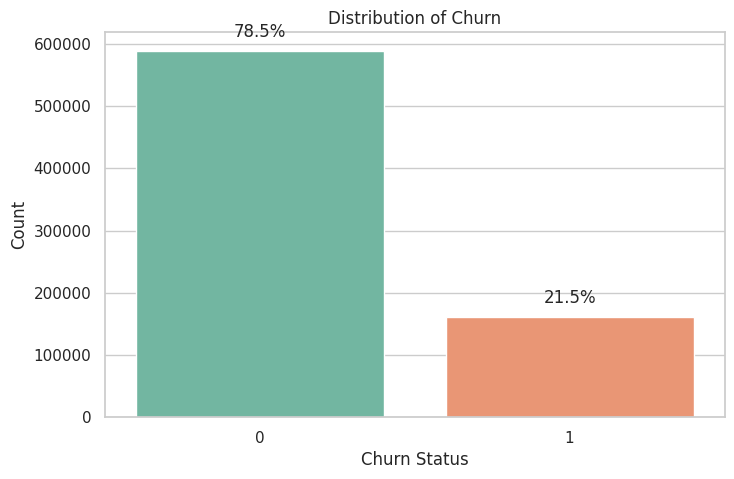

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Set plot style
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

print("--- 1. Target Variable Distribution: Churn ---")
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='CHURN', data=df_new_contract_dates_aggregated, palette='Set2')
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')

# Add percentage labels
total = len(df_new_contract_dates_aggregated)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

--- 2. Numerical Features Analysis ---


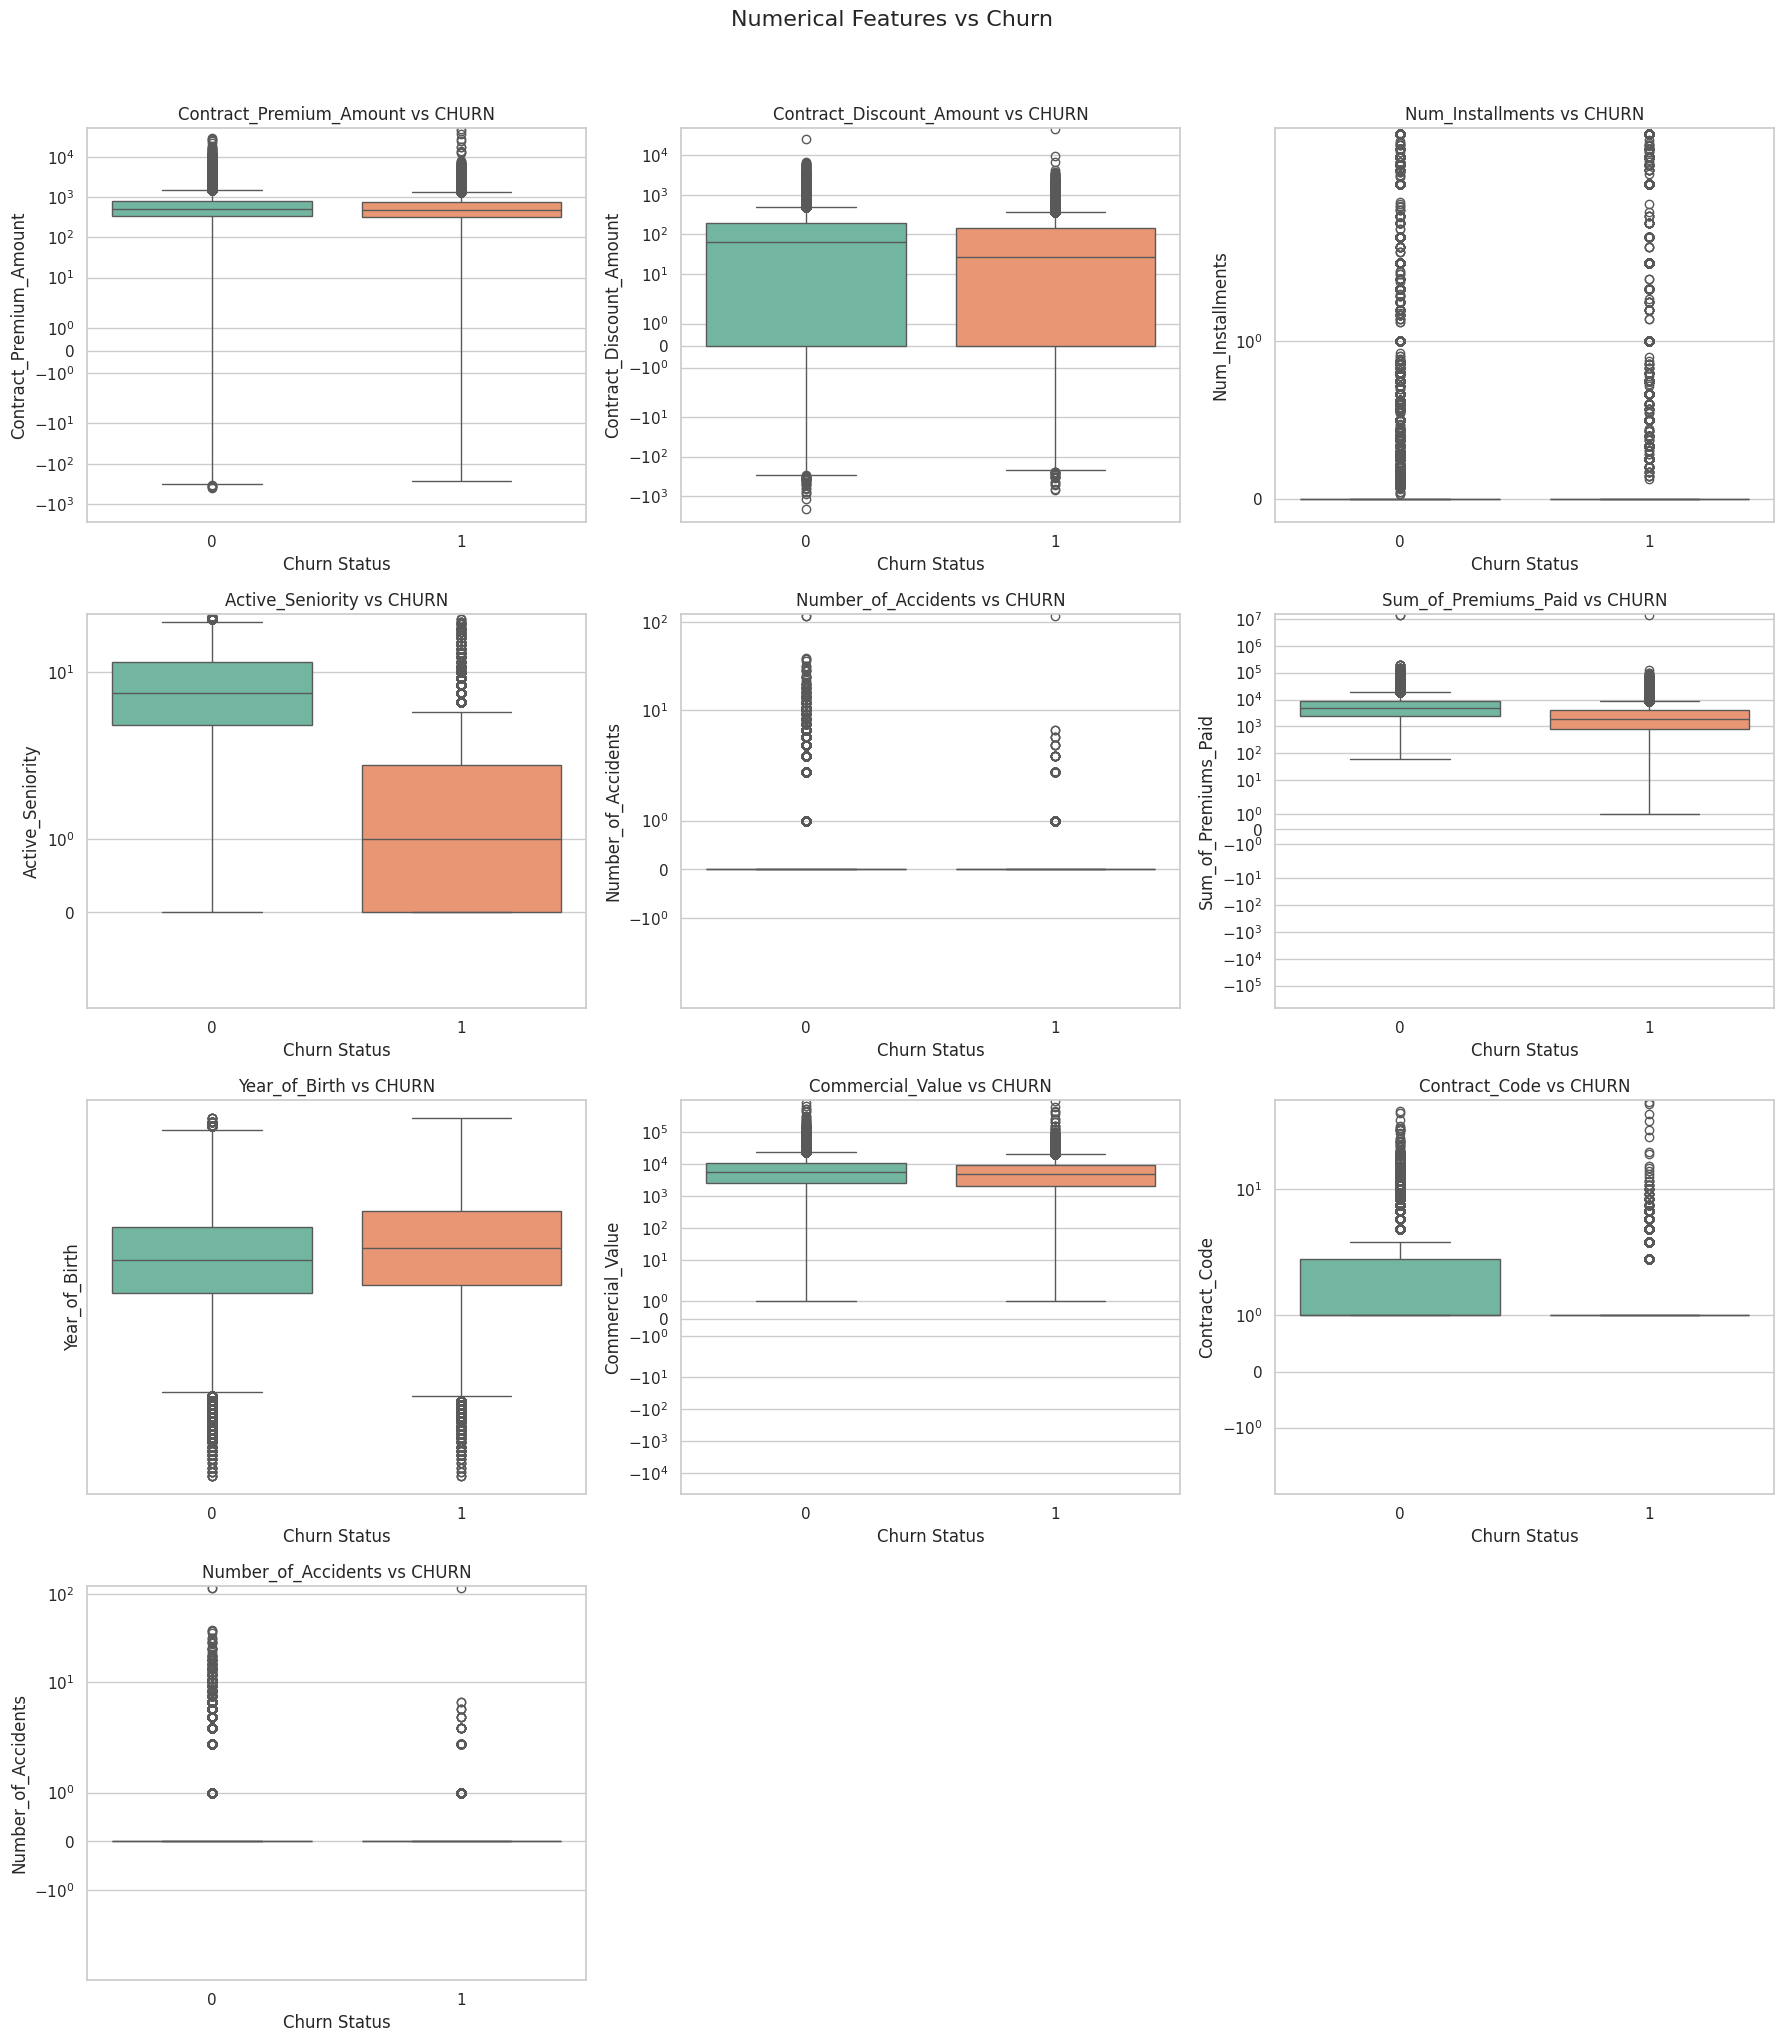

In [ ]:
print("--- 2. Numerical Features Analysis ---")

# All numerical columns from your aggregation
numerical_cols = [
    'Contract_Premium_Amount',   # sum
    'Contract_Discount_Amount',  # sum
    'Num_Installments',          # mean
    'Active_Seniority',          # max
    'Number_of_Accidents',       # max
    'Sum_of_Premiums_Paid',      # max
    'Year_of_Birth',             # max
    'Commercial_Value',          # max
    'Contract_Code',             # count → total contracts per year
    'Number_of_Accidents'
]

# Calculate grid dimensions dynamically
n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()  # flatten to iterate easily

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x='CHURN', y=col,
        data=df_new_contract_dates_aggregated,
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{col} vs CHURN', fontsize=12)
    axes[i].set_xlabel('Churn Status')
    axes[i].set_ylabel(col)
    axes[i].set_yscale('symlog')  # handles outliers and skewed distributions

# Hide empty subplots if grid has extra cells
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Churn', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Prepare data
df_temp = df_new_contract_dates_aggregated.copy()
df_temp['Number_of_Accidents_Filled'] = df_temp['Number_of_Accidents'].fillna(0).astype(int)

# Group high accident counts
max_accidents_to_show = 5
df_temp['Number_of_Accidents_Grouped'] = df_temp['Number_of_Accidents_Filled'].apply(
    lambda x: str(x) if x < max_accidents_to_show else f'{max_accidents_to_show}+'
)

# Build summary table
total = len(df_temp)
order = [str(i) for i in range(max_accidents_to_show)] + [f'{max_accidents_to_show}+']

summary = (
    df_temp
    .groupby(['Number_of_Accidents_Grouped', 'CHURN'])
    .size()
    .reset_index(name='COUNT')
)
summary['CHURN_LABEL'] = summary['CHURN'].map({0: 'No Churn', 1: 'Churn'})

# Pivot to wide format
table = summary.pivot(
    index='Number_of_Accidents_Grouped',
    columns='CHURN_LABEL',
    values='COUNT'
).reindex(order).fillna(0).astype(int)

# Add totals and proportions
table['Total']          = table.sum(axis=1)
table['% No Churn']     = (table['No Churn'] / table['Total'] * 100).round(1).astype(str) + '%'
table['% Churn']        = (table['Churn']    / table['Total'] * 100).round(1).astype(str) + '%'
table['% of Dataset']   = (table['Total']    / total          * 100).round(1).astype(str) + '%'

# Add grand total row
grand_total = pd.DataFrame({
    'No Churn'    : [table['No Churn'].sum()],
    'Churn'       : [table['Churn'].sum()],
    'Total'       : [table['Total'].sum()],
    '% No Churn'  : [f"{table['No Churn'].sum() / total * 100:.1f}%"],
    '% Churn'     : [f"{table['Churn'].sum()    / total * 100:.1f}%"],
    '% of Dataset': ['100.0%']
}, index=['TOTAL'])

table = pd.concat([table, grand_total])

# Display
print("=" * 70)
print("CHURN DISTRIBUTION BY NUMBER OF ACCIDENTS")
print("=" * 70)
print(table.to_string())
print("=" * 70)

CHURN DISTRIBUTION BY NUMBER OF ACCIDENTS
        Churn  No Churn   Total % No Churn % Churn % of Dataset
0      160906    575472  736378      78.1%   21.9%        98.1%
1         178      7250    7428      97.6%    2.4%         1.0%
2          54      3508    3562      98.5%    1.5%         0.5%
3          10      1451    1461      99.3%    0.7%         0.2%
4           4       854     858      99.5%    0.5%         0.1%
5+          6       879     885      99.3%    0.7%         0.1%
TOTAL  161158    589414  750572      78.5%   21.5%       100.0%


## 6.2 Key features analysis

Coverage columns found: 13


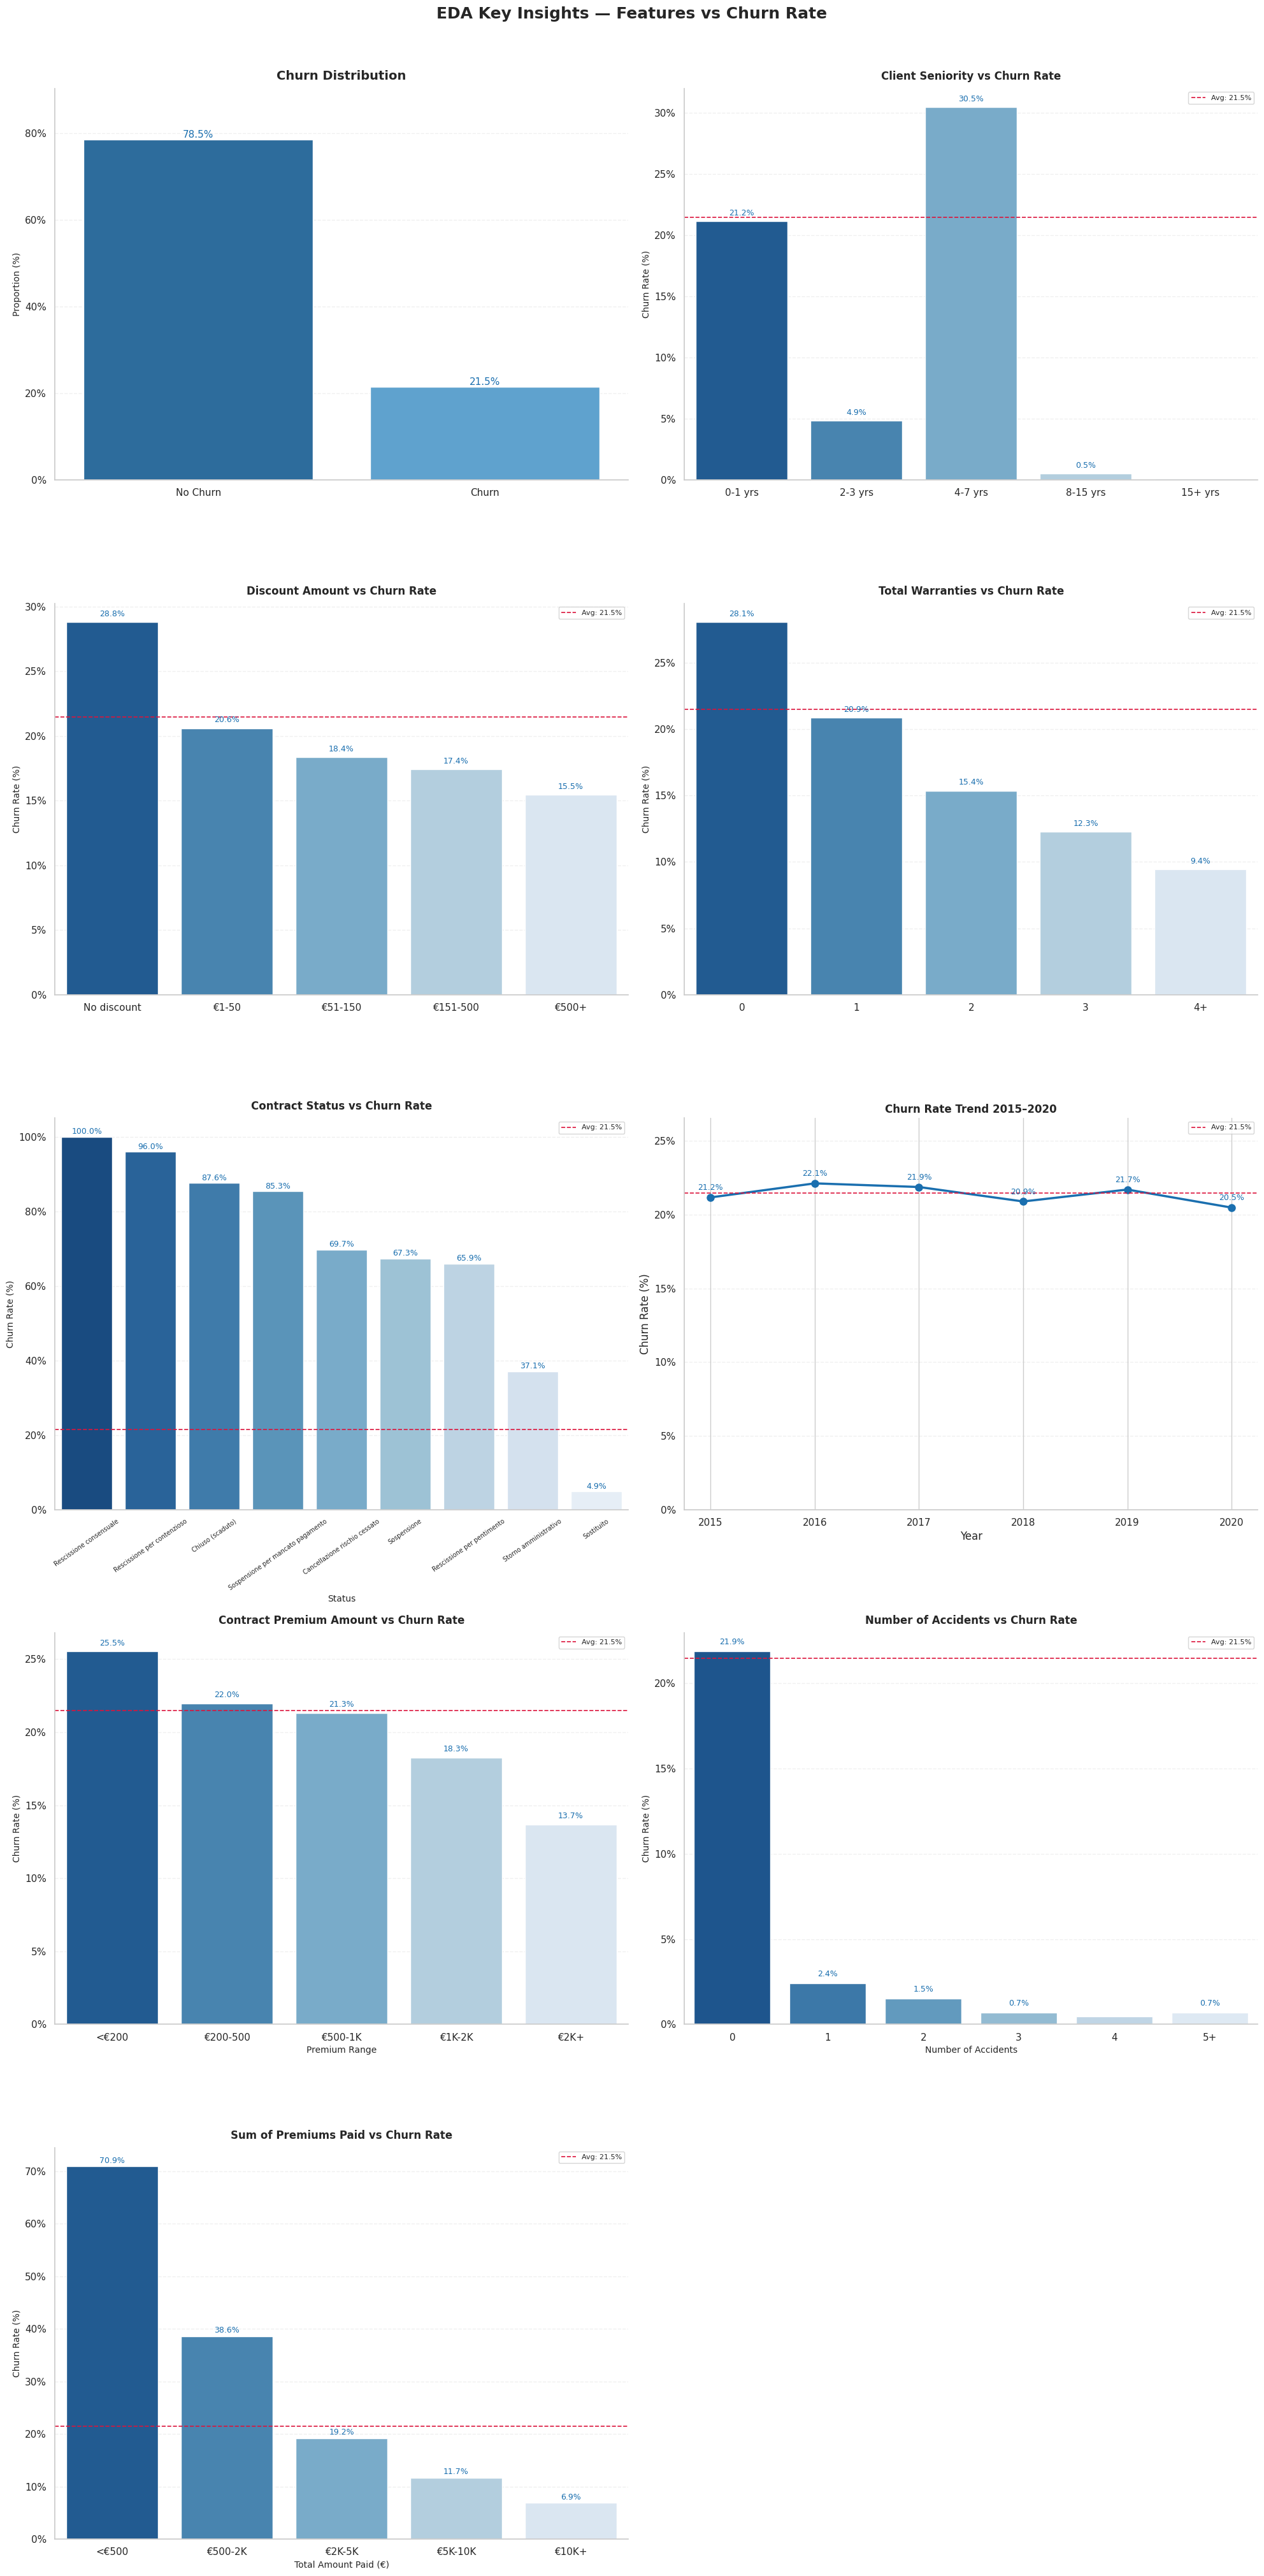

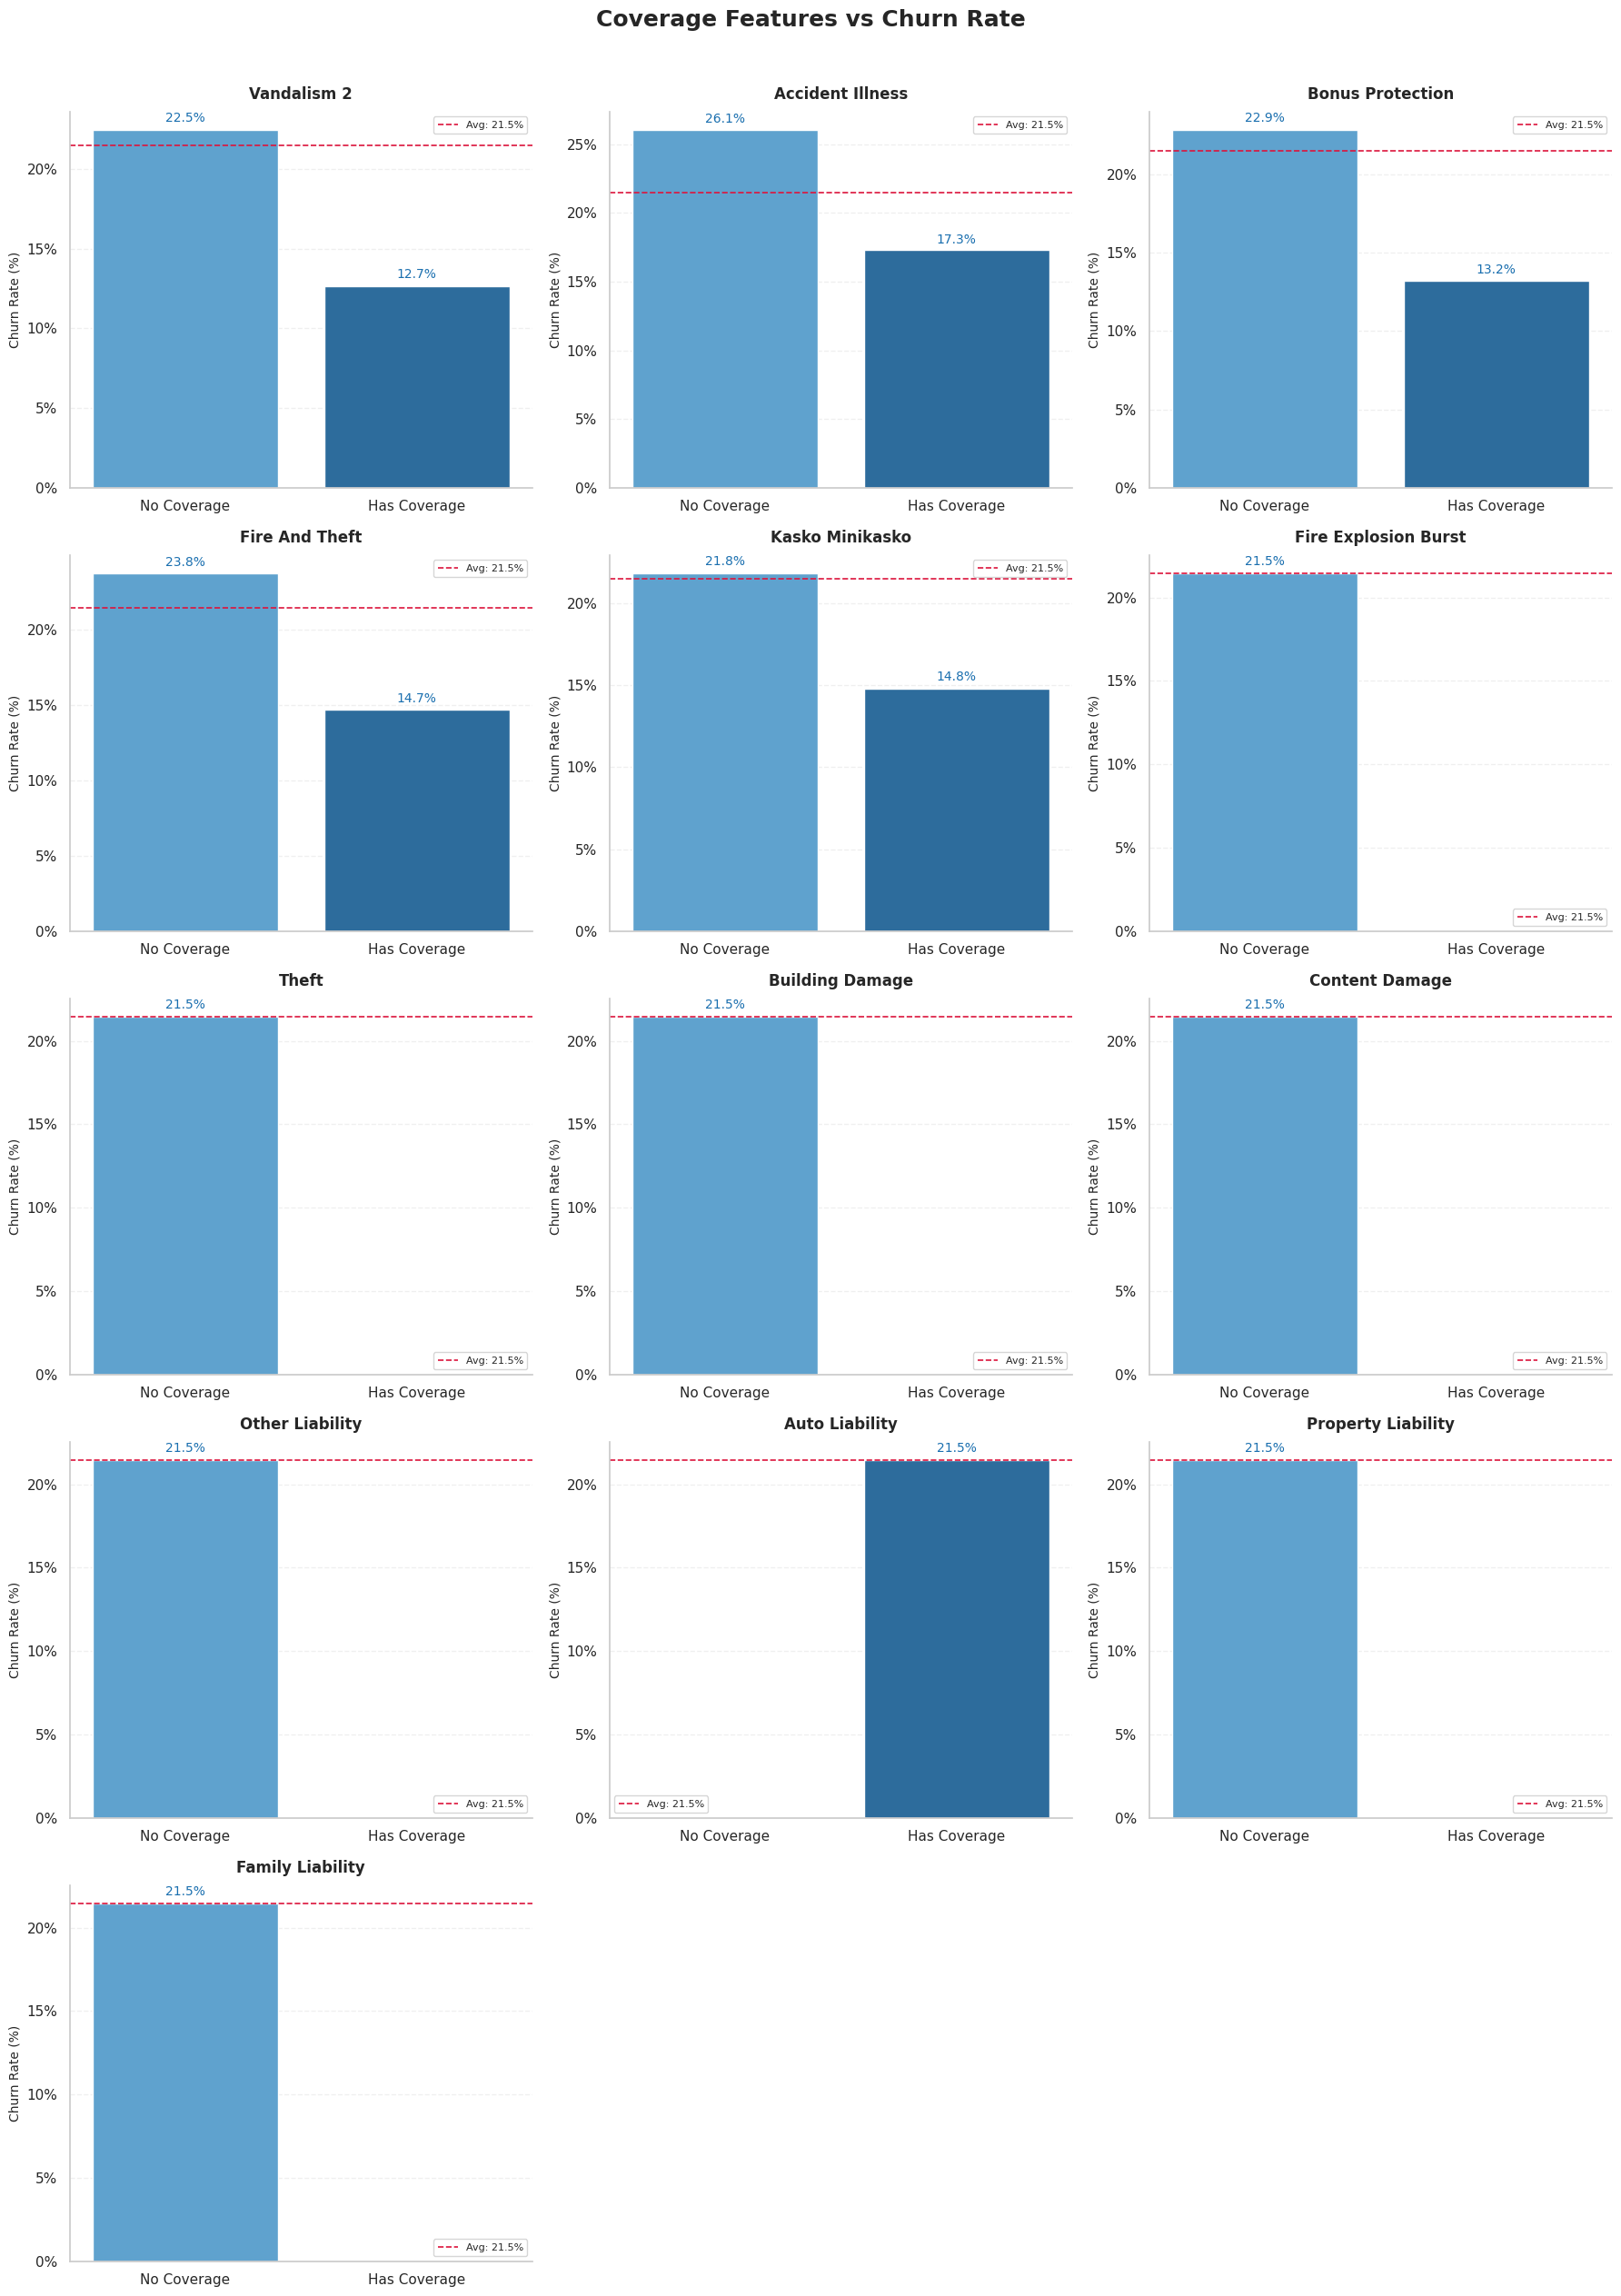

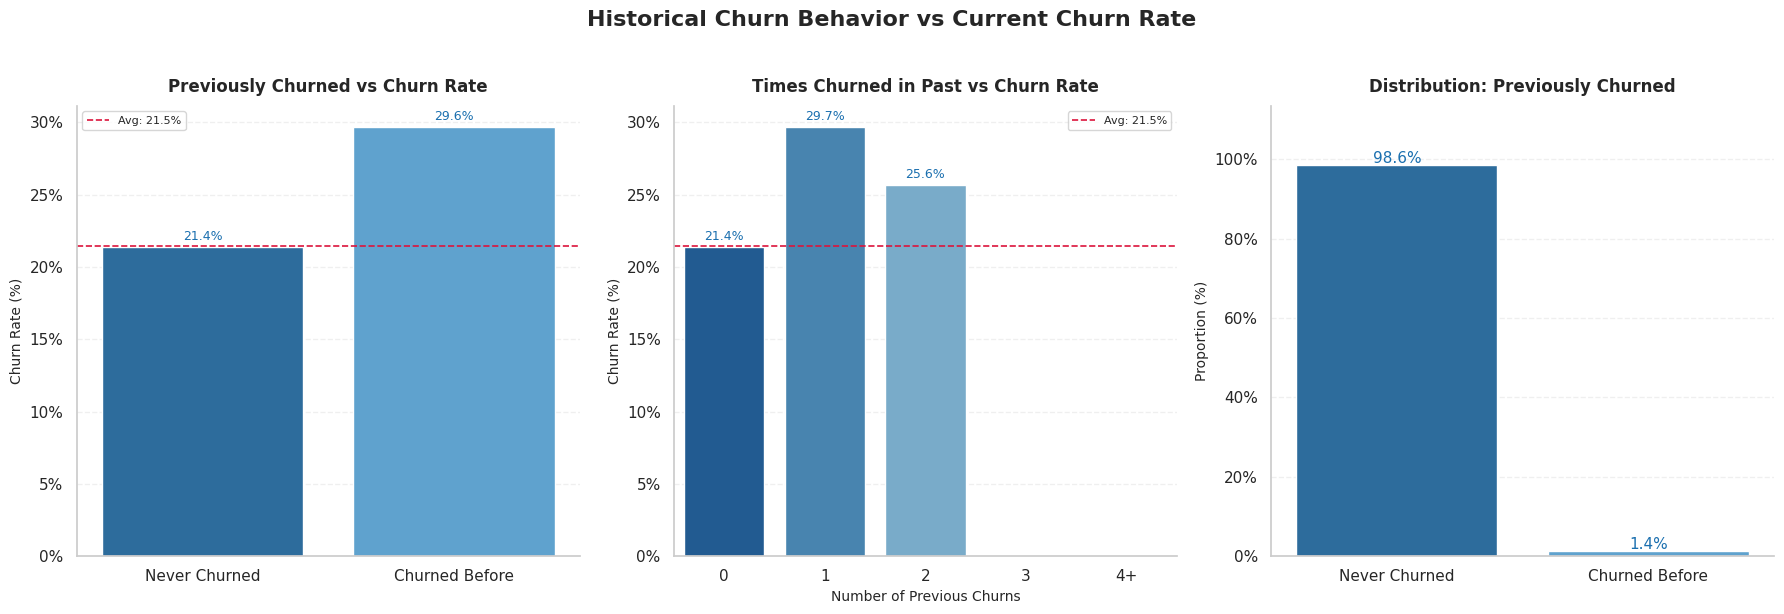

✅ Charts saved:
   - EDA_Key_Insights.png
   - EDA_Coverage_vs_Churn.png
   - EDA_Previously_Churned.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

avg_churn = df_new_contract_dates_aggregated['CHURN'].mean() * 100

def style_ax(ax, title, xlabel='', ylabel='Churn Rate (%)'):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(
        y=avg_churn, color='crimson',
        linestyle='--', linewidth=1.2,
        label=f'Avg: {avg_churn:.1f}%'
    )
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

def add_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center', va='bottom',
                fontsize=9, color='#1a6faf'
            )

# ============================================================
# Coverage columns to analyze
# ============================================================
coverage_cols = [
    'Cov_Vandalism_2',
    'Cov_Accident_Illness',
    'Cov_Bonus_Protection',
    'Cov_Fire_And_Theft',
    'Cov_Kasko_MiniKasko',
    'Cov_Fire_Explosion_Burst',
    'Cov_Theft',
    'Cov_Building_Damage',
    'Cov_Content_Damage',
    'Cov_Other_Liability',
    'Cov_Auto_Liability',
    'Cov_Property_Liability',
    'Cov_Family_Liability',
]

coverage_cols = [
    col for col in coverage_cols
    if col in df_new_contract_dates_aggregated.columns
]

print(f"Coverage columns found: {len(coverage_cols)}")

# ============================================================
# Figure 1 — 9 charts (5x2 grid)  ← changed from 4x2
# ============================================================
fig = plt.figure(figsize=(20, 40))   # ← height increased for extra row
fig.suptitle(
    'EDA Key Insights — Features vs Churn Rate',
    fontsize=18, fontweight='bold', y=1.01
)

# Chart 1 — Churn Distribution
ax1 = fig.add_subplot(5, 2, 1)      # ← 5 rows now
churn_counts = df_new_contract_dates_aggregated['CHURN'].value_counts().reset_index()
churn_counts.columns = ['CHURN', 'COUNT']
churn_counts['PROPORTION'] = churn_counts['COUNT'] / churn_counts['COUNT'].sum() * 100
churn_counts['LABEL'] = churn_counts['CHURN'].map({0: 'No Churn', 1: 'Churn'})
churn_counts = churn_counts.sort_values('CHURN')
sns.barplot(data=churn_counts, x='LABEL', y='PROPORTION',
            palette=['#1a6faf', '#4da6e0'], ax=ax1)
for i, row in churn_counts.reset_index(drop=True).iterrows():
    ax1.text(i, row['PROPORTION'] + 0.5, f"{row['PROPORTION']:.1f}%",
             ha='center', fontsize=11, color='#1a6faf')
ax1.set_title('Churn Distribution', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('')
ax1.set_ylabel('Proportion (%)', fontsize=10)
ax1.set_ylim(0, churn_counts['PROPORTION'].max() * 1.15)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 — Active Seniority
ax2 = fig.add_subplot(5, 2, 2)
df_temp = df_new_contract_dates_aggregated.copy()
df_temp['Active_Seniority'] = df_temp['Active_Seniority'].fillna(
    df_temp['Active_Seniority'].median())
df_temp['Seniority_Segment'] = pd.cut(
    df_temp['Active_Seniority'],
    bins=[-1, 1, 3, 7, 15, 999],
    labels=['0-1 yrs', '2-3 yrs', '4-7 yrs', '8-15 yrs', '15+ yrs'])
churn_seniority = (df_temp.groupby('Seniority_Segment')['CHURN']
                   .mean() * 100).reset_index()
churn_seniority.columns = ['Seniority_Segment', 'Churn_Rate']
sns.barplot(data=churn_seniority, x='Seniority_Segment', y='Churn_Rate',
            palette='Blues_r', ax=ax2)
add_labels(ax2)
style_ax(ax2, 'Client Seniority vs Churn Rate')

# Chart 3 — Contract Discount
ax3 = fig.add_subplot(5, 2, 3)
df_temp['Discount_Segment'] = pd.cut(
    df_new_contract_dates_aggregated['Contract_Discount_Amount'],
    bins=[-1, 0, 50, 150, 500, 999999],
    labels=['No discount', '€1-50', '€51-150', '€151-500', '€500+'])
churn_discount = (df_temp.groupby('Discount_Segment')['CHURN']
                  .mean() * 100).reset_index()
churn_discount.columns = ['Discount_Segment', 'Churn_Rate']
sns.barplot(data=churn_discount, x='Discount_Segment', y='Churn_Rate',
            palette='Blues_r', ax=ax3)
add_labels(ax3)
style_ax(ax3, 'Discount Amount vs Churn Rate')

# Chart 4 — Total Warranties
ax4 = fig.add_subplot(5, 2, 4)
if 'Total_Warranties' not in df_new_contract_dates_aggregated.columns:
    cov_cols_sum = ['Cov_Vandalism_2', 'Cov_Accident_Illness',
                    'Cov_Bonus_Protection', 'Cov_Fire_And_Theft', 'Cov_Kasko_MiniKasko']
    df_new_contract_dates_aggregated['Total_Warranties'] = (
        df_new_contract_dates_aggregated[cov_cols_sum].sum(axis=1))
df_temp['Total_Warranties_Segment'] = pd.cut(
    df_new_contract_dates_aggregated['Total_Warranties'],
    bins=[-1, 0, 1, 2, 3, 999],
    labels=['0', '1', '2', '3', '4+'])
churn_warranties = (df_temp.groupby('Total_Warranties_Segment')['CHURN']
                    .mean() * 100).reset_index()
churn_warranties.columns = ['Total_Warranties_Segment', 'Churn_Rate']
sns.barplot(data=churn_warranties, x='Total_Warranties_Segment', y='Churn_Rate',
            palette='Blues_r', ax=ax4)
add_labels(ax4)
style_ax(ax4, 'Total Warranties vs Churn Rate')

# Chart 5 — Status
ax5 = fig.add_subplot(5, 2, 5)
churn_status = (df_new_contract_dates_aggregated.groupby('Status')['CHURN']
                .mean() * 100).reset_index()
churn_status.columns = ['Status', 'Churn_Rate']
churn_status = churn_status.sort_values('Churn_Rate', ascending=False)
sns.barplot(data=churn_status, x='Status', y='Churn_Rate',
            palette='Blues_r', ax=ax5)
add_labels(ax5)
style_ax(ax5, 'Contract Status vs Churn Rate', xlabel='Status')
ax5.tick_params(axis='x', rotation=35, labelsize=7)

# Chart 6 — Temporal Trend
ax6 = fig.add_subplot(5, 2, 6)
churn_by_year = (
    df_new_contract_dates_aggregated
    [df_new_contract_dates_aggregated['Expiry__Year'] <= 2020]
    .groupby('Expiry__Year')['CHURN'].mean() * 100).reset_index()
churn_by_year.columns = ['Year', 'Churn_Rate']
ax6.plot(churn_by_year['Year'], churn_by_year['Churn_Rate'],
         color='#1a6faf', linewidth=2.5, marker='o', markersize=8)
for _, row in churn_by_year.iterrows():
    ax6.text(row['Year'], row['Churn_Rate'] + 0.5,
             f"{row['Churn_Rate']:.1f}%", ha='center', fontsize=9, color='#1a6faf')
ax6.axhline(y=avg_churn, color='crimson', linestyle='--',
            linewidth=1.2, label=f'Avg: {avg_churn:.1f}%')
ax6.set_title('Churn Rate Trend 2015–2020', fontsize=12, fontweight='bold')
ax6.set_xlabel('Year')
ax6.set_ylabel('Churn Rate (%)')
ax6.set_ylim(0, churn_by_year['Churn_Rate'].max() * 1.2)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax6.grid(axis='y', linestyle='--', alpha=0.3)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.legend(fontsize=8)

# Chart 7 — Premium Amount
ax7 = fig.add_subplot(5, 2, 7)
df_temp['Premium_Segment'] = pd.cut(
    df_new_contract_dates_aggregated['Contract_Premium_Amount'],
    bins=[-1, 200, 500, 1000, 2000, 999999],
    labels=['<€200', '€200-500', '€500-1K', '€1K-2K', '€2K+'])
churn_premium = (df_temp.groupby('Premium_Segment')['CHURN']
                 .mean() * 100).reset_index()
churn_premium.columns = ['Premium_Segment', 'Churn_Rate']
sns.barplot(data=churn_premium, x='Premium_Segment', y='Churn_Rate',
            palette='Blues_r', ax=ax7)
add_labels(ax7)
style_ax(ax7, 'Contract Premium Amount vs Churn Rate', xlabel='Premium Range')

# Chart 8 — Number of Accidents
ax8 = fig.add_subplot(5, 2, 8)
df_temp['Number_of_Accidents_Filled'] = (
    df_new_contract_dates_aggregated['Number_of_Accidents'].fillna(0).astype(int))
max_accidents = 5
df_temp['Accidents_Grouped'] = df_temp['Number_of_Accidents_Filled'].apply(
    lambda x: str(x) if x < max_accidents else f'{max_accidents}+')
churn_accidents = (df_temp.groupby('Accidents_Grouped')['CHURN']
                   .mean() * 100).reset_index()
churn_accidents.columns = ['Accidents_Grouped', 'Churn_Rate']
order = [str(i) for i in range(max_accidents)] + [f'{max_accidents}+']
sns.barplot(data=churn_accidents, x='Accidents_Grouped', y='Churn_Rate',
            palette='Blues_r', ax=ax8, order=order)
add_labels(ax8)
style_ax(ax8, 'Number of Accidents vs Churn Rate', xlabel='Number of Accidents')

# ============================================================
# Chart 9 — Sum of Premiums Paid vs Churn Rate  ← NEW
# ============================================================
ax9 = fig.add_subplot(5, 2, 9)
df_temp['Sum_Premiums_Segment'] = pd.cut(
    df_new_contract_dates_aggregated['Sum_of_Premiums_Paid'].fillna(0),
    bins=[-1, 500, 2000, 5000, 10000, 999999],
    labels=['<€500', '€500-2K', '€2K-5K', '€5K-10K', '€10K+']
)
churn_sum_premiums = (
    df_temp.groupby('Sum_Premiums_Segment')['CHURN']
    .mean() * 100
).reset_index()
churn_sum_premiums.columns = ['Sum_Premiums_Segment', 'Churn_Rate']

sns.barplot(
    data=churn_sum_premiums,
    x='Sum_Premiums_Segment', y='Churn_Rate',
    palette='Blues_r', ax=ax9
)
add_labels(ax9)
style_ax(
    ax9,
    'Sum of Premiums Paid vs Churn Rate',
    xlabel='Total Amount Paid (€)'
)

# ax10 left empty — hide it
ax10 = fig.add_subplot(5, 2, 10)
ax10.set_visible(False)

plt.tight_layout()
plt.savefig('EDA_Key_Insights.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Figure 2 — Coverage columns vs Churn Rate
# ============================================================
n_cols = 3
n_rows = -(-len(coverage_cols) // n_cols)

fig2, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
fig2.suptitle('Coverage Features vs Churn Rate',
              fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(coverage_cols):
    df_cov = df_new_contract_dates_aggregated[[col, 'CHURN']].copy()
    df_cov[col] = df_cov[col].fillna(0)
    df_cov['Coverage_Label'] = df_cov[col].map({0: 'No Coverage', 1: 'Has Coverage'})
    churn_cov = (df_cov.groupby('Coverage_Label')['CHURN']
                 .mean() * 100).reset_index()
    churn_cov.columns = ['Coverage_Label', 'Churn_Rate']
    title = col.replace('Cov_', '').replace('_', ' ').title()
    sns.barplot(data=churn_cov, x='Coverage_Label', y='Churn_Rate',
                palette=['#4da6e0', '#1a6faf'],
                order=['No Coverage', 'Has Coverage'], ax=axes[i])
    for bar in axes[i].patches:
        height = bar.get_height()
        if height > 0.5:
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         height + 0.3, f'{height:.1f}%',
                         ha='center', va='bottom', fontsize=10, color='#1a6faf')
    style_ax(axes[i], title, xlabel='')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('EDA_Coverage_vs_Churn.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Figure 3 — Previously Churned vs Churn Rate
# ============================================================
if 'Previously_Churned' not in df_new_contract_dates_aggregated.columns:
    df_new_contract_dates_aggregated = df_new_contract_dates_aggregated.sort_values(
        ['Client_ID', 'Expiry__Year']
    ).reset_index(drop=True)
    df_new_contract_dates_aggregated['Previously_Churned'] = (
        df_new_contract_dates_aggregated
        .groupby('Client_ID')['CHURN']
        .apply(lambda x: x.shift(1).expanding().max().fillna(0).astype(int))
        .reset_index(level=0, drop=True)
    )
    df_new_contract_dates_aggregated['Times_Churned'] = (
        df_new_contract_dates_aggregated
        .groupby('Client_ID')['CHURN']
        .apply(lambda x: x.shift(1).expanding().sum().fillna(0).astype(int))
        .reset_index(level=0, drop=True)
    )

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))
fig3.suptitle('Historical Churn Behavior vs Current Churn Rate',
              fontsize=16, fontweight='bold', y=1.02)

# Chart 1 — Previously Churned Yes/No
churn_prev = (df_new_contract_dates_aggregated
              .groupby('Previously_Churned')['CHURN']
              .mean() * 100).reset_index()
churn_prev.columns = ['Previously_Churned', 'Churn_Rate']
churn_prev['Label'] = churn_prev['Previously_Churned'].map(
    {0: 'Never Churned', 1: 'Churned Before'})
sns.barplot(data=churn_prev, x='Label', y='Churn_Rate',
            palette=['#1a6faf', '#4da6e0'], ax=axes3[0])
add_labels(axes3[0])
style_ax(axes3[0], 'Previously Churned vs Churn Rate', xlabel='')

# Ensure Times_Churned exists (in case Previously_Churned was pre-computed
# in an earlier cell and the if-block above was skipped)
if 'Times_Churned' not in df_new_contract_dates_aggregated.columns:
    df_new_contract_dates_aggregated['Times_Churned'] = (
        df_new_contract_dates_aggregated
        .groupby('Client_ID')['CHURN']
        .apply(lambda x: x.shift(1).expanding().sum().fillna(0).astype(int))
        .reset_index(level=0, drop=True)
    )

# Chart 2 — Times Churned
df_times = df_new_contract_dates_aggregated.copy()
df_times['Times_Churned_Grouped'] = df_times['Times_Churned'].apply(
    lambda x: str(int(x)) if x < 4 else '4+')
churn_times = (df_times.groupby('Times_Churned_Grouped')['CHURN']
               .mean() * 100).reset_index()
churn_times.columns = ['Times_Churned_Grouped', 'Churn_Rate']
order_times = ['0', '1', '2', '3', '4+']
sns.barplot(data=churn_times, x='Times_Churned_Grouped', y='Churn_Rate',
            palette='Blues_r', order=order_times, ax=axes3[1])
add_labels(axes3[1])
style_ax(axes3[1], 'Times Churned in Past vs Churn Rate',
         xlabel='Number of Previous Churns')

# Chart 3 — Distribution Previously Churned
prev_counts = (df_new_contract_dates_aggregated['Previously_Churned']
               .value_counts().reset_index())
prev_counts.columns = ['Previously_Churned', 'COUNT']
prev_counts['PROPORTION'] = prev_counts['COUNT'] / prev_counts['COUNT'].sum() * 100
prev_counts['Label'] = prev_counts['Previously_Churned'].map(
    {0: 'Never Churned', 1: 'Churned Before'})
prev_counts = prev_counts.sort_values('Previously_Churned')
sns.barplot(data=prev_counts, x='Label', y='PROPORTION',
            palette=['#1a6faf', '#4da6e0'], ax=axes3[2])
for i, row in prev_counts.reset_index(drop=True).iterrows():
    axes3[2].text(i, row['PROPORTION'] + 0.5, f"{row['PROPORTION']:.1f}%",
                  ha='center', fontsize=11, color='#1a6faf')
axes3[2].set_title('Distribution: Previously Churned',
                   fontsize=12, fontweight='bold', pad=10)
axes3[2].set_xlabel('')
axes3[2].set_ylabel('Proportion (%)', fontsize=10)
axes3[2].set_ylim(0, prev_counts['PROPORTION'].max() * 1.15)
axes3[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes3[2].grid(axis='y', linestyle='--', alpha=0.3)
axes3[2].spines['top'].set_visible(False)
axes3[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('EDA_Previously_Churned.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Charts saved:")
print("   - EDA_Key_Insights.png")
print("   - EDA_Coverage_vs_Churn.png")
print("   - EDA_Previously_Churned.png")

--- 4. Warranty Indicators and Correlation Matrix ---


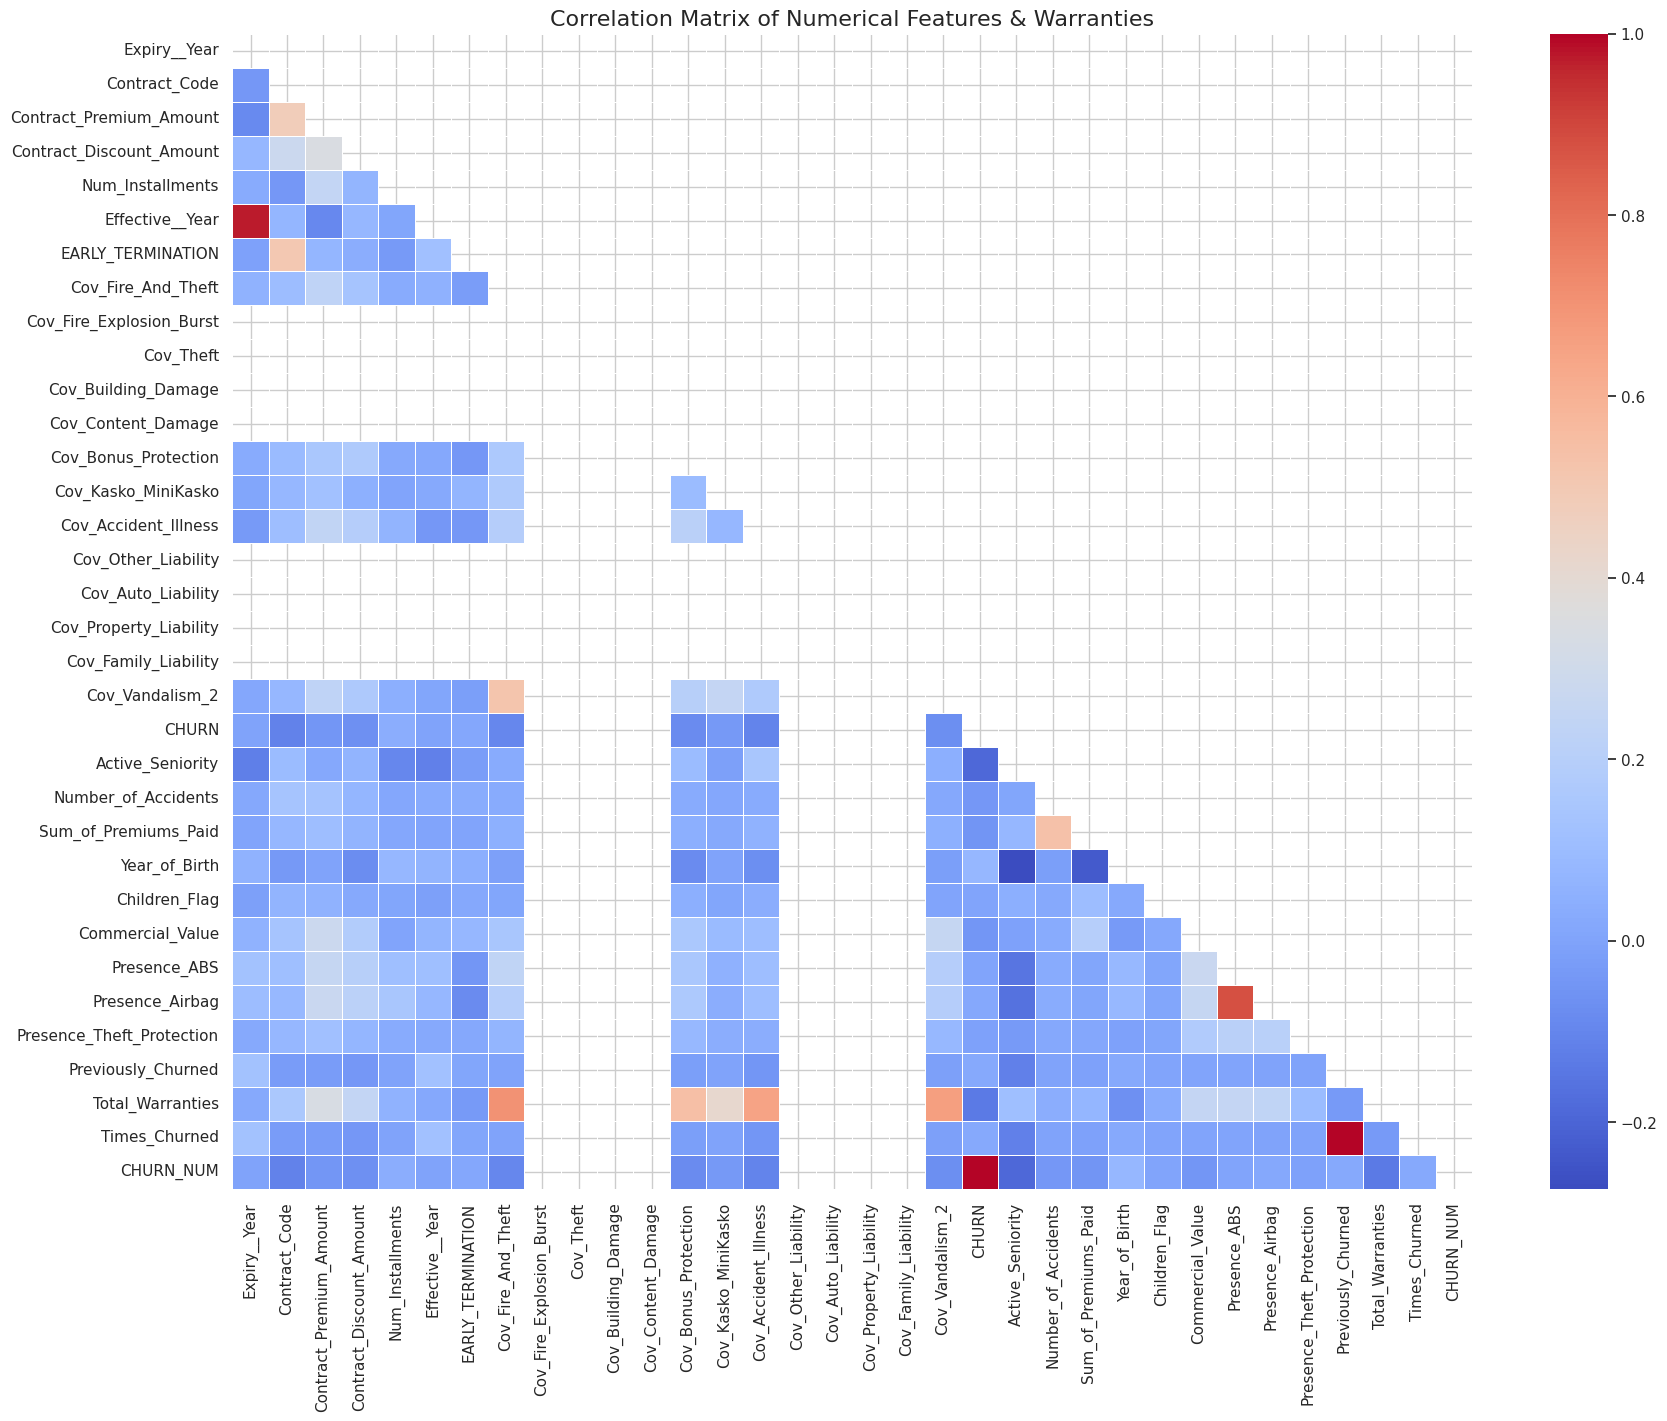

In [ ]:
print("--- 4. Warranty Indicators and Correlation Matrix ---")
numeric_df = df_new_contract_dates_aggregated.select_dtypes(include=['int64', 'float64', 'int32'])
numeric_df['CHURN_NUM'] = df_new_contract_dates_aggregated['CHURN'].map({1: 1, 0: 0}) # Map 1/0 to 1/0

plt.figure(figsize=(20, 15))
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features & Warranties', fontsize=16)
plt.show()

--- 5. Temporal Trend Analysis ---


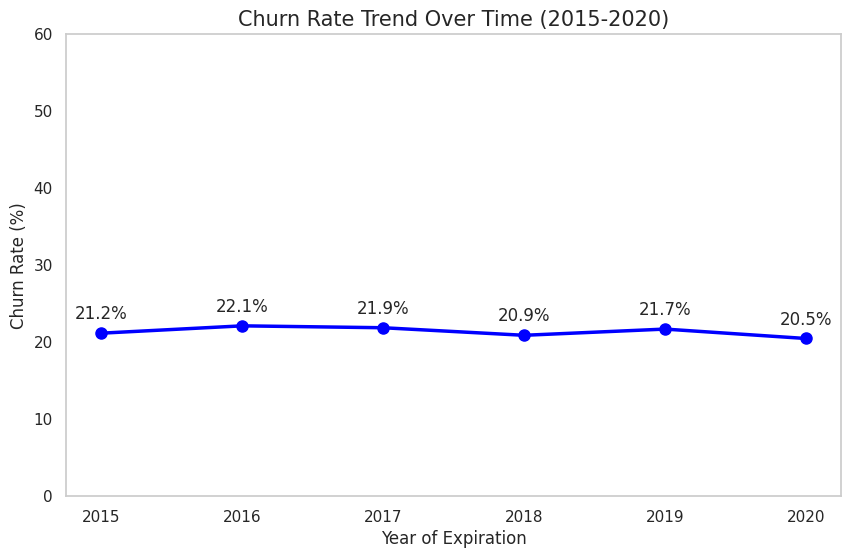

In [ ]:
print("--- 5. Temporal Trend Analysis ---")
# Calculate churn rate percentage per year
churn_by_year = df_new_contract_dates_aggregated.groupby('Expiry__Year')['CHURN'].value_counts(normalize=True).unstack() * 100

# Filter data to include only years up to 2020
churn_by_year_filtered = churn_by_year[churn_by_year.index <= 2020]

plt.figure(figsize=(10, 6))
churn_by_year_filtered[1].plot(kind='line', marker='o', color='blue', linewidth=2.5, markersize=8) # Use 1 for churn
plt.title('Churn Rate Trend Over Time (2015-2020)', fontsize=15)
plt.xlabel('Year of Expiration', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(churn_by_year_filtered.index)
plt.grid(False)

# Annotate the data points
for x, y in zip(churn_by_year_filtered.index, churn_by_year_filtered[1]): # Use 1 for churn
    plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.ylim(0, 60)
plt.show()

--- 6. Impact of Specific Warranties on Churn ---


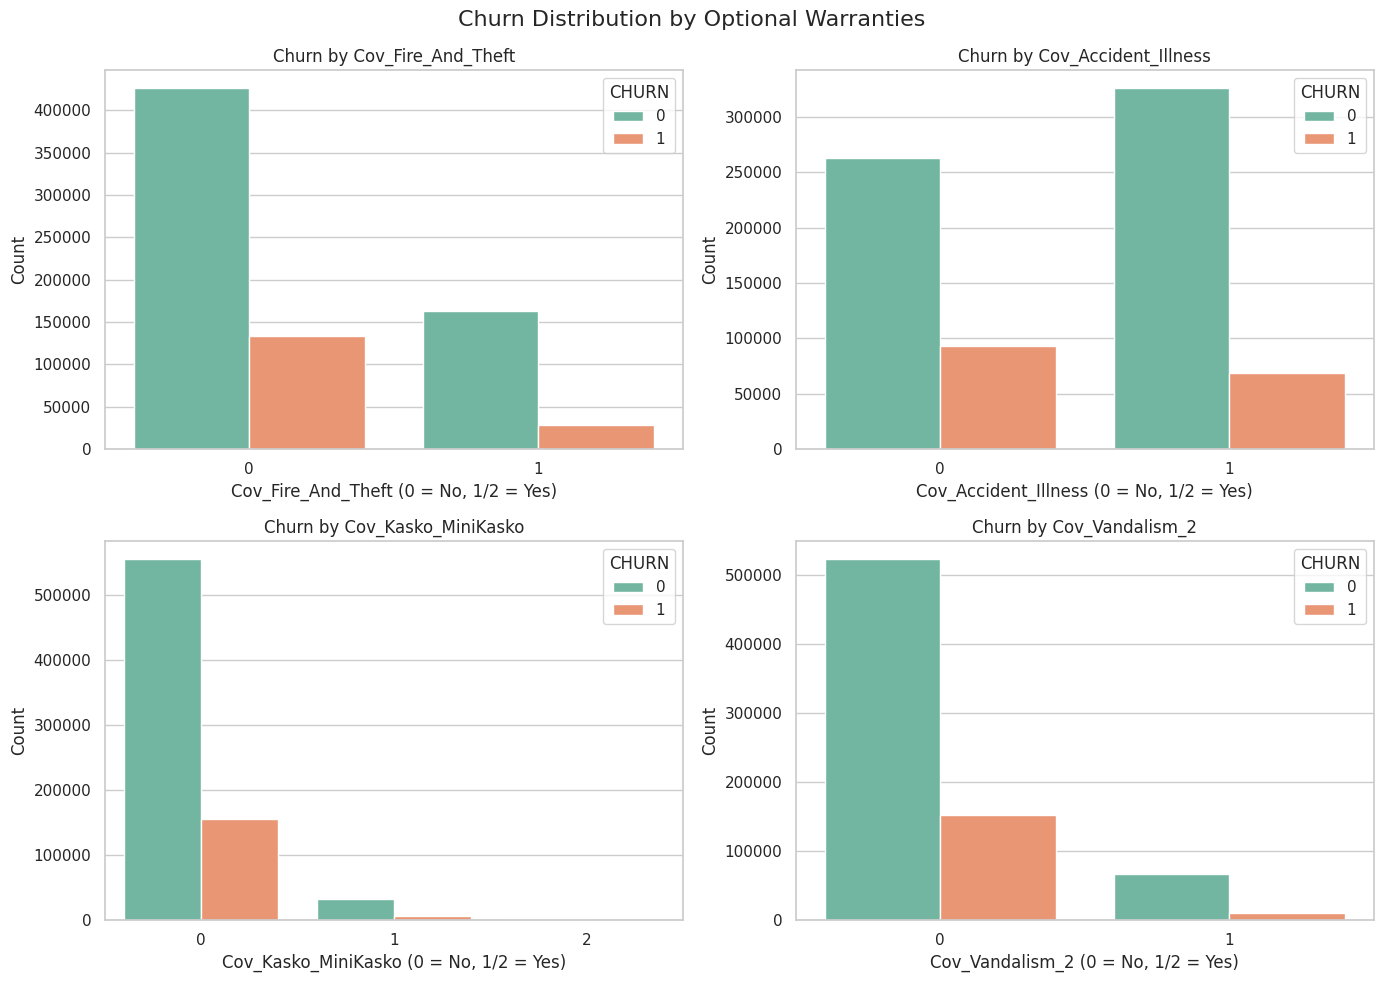

In [ ]:
print("--- 6. Impact of Specific Warranties on Churn ---")
# Select a few key optional warranties to analyze
warranties_to_check = ['Cov_Fire_And_Theft', 'Cov_Accident_Illness', 'Cov_Kasko_MiniKasko', 'Cov_Vandalism_2']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Distribution by Optional Warranties', fontsize=16)

for i, warranty in enumerate(warranties_to_check):
    row, col = divmod(i, 2)
    ax = sns.countplot(x=warranty, hue='CHURN', data=df_new_contract_dates_aggregated, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'Churn by {warranty}')
    axes[row, col].set_xlabel(f'{warranty} (0 = No, 1/2 = Yes)')
    axes[row, col].set_ylabel('Count')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust layout to make room for the main title
plt.show()

# 7. Selecting features

In [ ]:
selected_categorical = [
    'Status',
    'Risk',
    'Product',
    'Business_Grouping',
    'Payment_Method_Signing',
    'Installment_Payment_Method',
]

## 7.1 Extract correlation with churn

FEATURE CORRELATION WITH CHURN
CHURN                        1.0000
Active_Seniority             0.1910
Total_Warranties             0.1384
Contract_Code                0.1107
Cov_Accident_Illness         0.1066
Cov_Fire_And_Theft           0.0966
Cov_Bonus_Protection         0.0822
Year_of_Birth                0.0781
Cov_Vandalism_2              0.0724
Contract_Discount_Amount     0.0690
Sum_of_Premiums_Paid         0.0502
Commercial_Value             0.0474
Contract_Premium_Amount      0.0457
Number_of_Accidents          0.0418
Cov_Kasko_MiniKasko          0.0380
Num_Installments             0.0352
Previously_Churned           0.0236
Times_Churned                0.0236
Presence_Airbag              0.0153
EARLY_TERMINATION            0.0132
Presence_Theft_Protection    0.0078
Expiry__Year                 0.0046
Presence_ABS                 0.0038
Effective__Year              0.0028
Children_Flag                0.0025
Cov_Fire_Explosion_Burst        NaN
Cov_Theft                       N

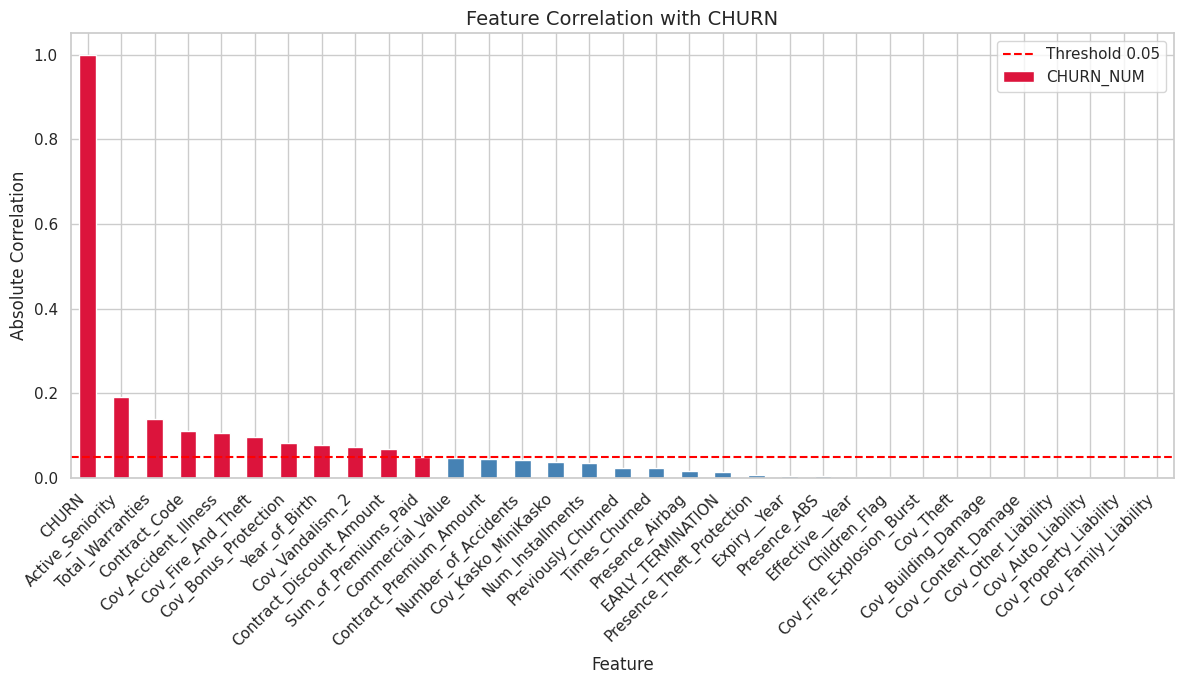

In [ ]:
# Based on correlation matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build numeric df with CHURN as numeric
numeric_df = df_new_contract_dates_aggregated.select_dtypes(include=['int64', 'float64', 'int32']).copy()
numeric_df['CHURN_NUM'] = df_new_contract_dates_aggregated['CHURN'].map({1: 1, 0: 0}) # Map 1/0 to 1/0

# Correlation of every feature WITH CHURN specifically
churn_corr = numeric_df.corr()['CHURN_NUM'].drop('CHURN_NUM').abs().sort_values(ascending=False)

print("=" * 50)
print("FEATURE CORRELATION WITH CHURN")
print("=" * 50)
print(churn_corr.round(4))

# Visualize
plt.figure(figsize=(12, 7))
churn_corr.plot(kind='bar', color=['crimson' if x > 0.05 else 'steelblue' for x in churn_corr])
plt.title('Feature Correlation with CHURN', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation')
plt.axhline(y=0.05, color='red', linestyle='--', label='Threshold 0.05')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7.2 Detect multicollinearity between features

In [ ]:
# Check features that are highly correlated WITH EACH OTHER
# These are redundant — keep only one from each pair

corr_matrix = numeric_df.drop(columns=['CHURN_NUM']).corr().abs()

# Find pairs with correlation > 0.80
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.80:
            high_corr_pairs.append({
                'Feature 1'  : corr_matrix.columns[i],
                'Feature 2'  : corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
if len(high_corr_df) > 0:
    print("Highly correlated feature pairs (>0.80) — consider dropping one:")
    print(high_corr_df.sort_values('Correlation', ascending=False))
else:
    print("No highly correlated feature pairs found")

Highly correlated feature pairs (>0.80) — consider dropping one:
            Feature 1        Feature 2  Correlation
2  Previously_Churned    Times_Churned        0.998
0        Expiry__Year  Effective__Year        0.974
1        Presence_ABS  Presence_Airbag        0.880


## 7.3 Select features based on results

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Drop redundant features from multicollinearity
cols_to_drop_multicollinearity = [
    'Effective__Year',   # corr=0.983 with Expiry__Year
    'Presence_Airbag',   # corr=0.871 with Presence_ABS
    # Leakage columns — these encode future/target-derived information
    'EARLY_TERMINATION',    # directly used to build CHURN label
    'NEXT_CONTRACT_DATE',   # directly used to build CHURN label
    'WINDOW_END',           # directly used to build CHURN label
    'Effective_Date',
    'Closing_Date',
    'Client_ID',
    'Contract_Code',
    'Status',
]

df_model = df_new_contract_dates_aggregated.drop(
    columns=cols_to_drop_multicollinearity,
    errors='ignore'
).copy()

# Step 2: Build numeric df — EXCLUDE the target CHURN from features to avoid spurious corr=1.0
numeric_df = df_model.drop(columns=['CHURN'], errors='ignore').select_dtypes(
    include=['int64', 'float64', 'int32']
).copy()

# Add CHURN as numeric target for correlation analysis only
numeric_df['CHURN_NUM'] = df_model['CHURN'].map({1: 1, 0: 0})
if numeric_df['CHURN_NUM'].isna().all():
    numeric_df['CHURN_NUM'] = df_model['CHURN'].astype(int)

print(f"Numeric features available: {numeric_df.shape[1] - 1}")
print(numeric_df.drop(columns=['CHURN_NUM']).columns.tolist())


Numeric features available: 28
['Expiry__Year', 'Contract_Premium_Amount', 'Contract_Discount_Amount', 'Num_Installments', 'Cov_Fire_And_Theft', 'Cov_Fire_Explosion_Burst', 'Cov_Theft', 'Cov_Building_Damage', 'Cov_Content_Damage', 'Cov_Bonus_Protection', 'Cov_Kasko_MiniKasko', 'Cov_Accident_Illness', 'Cov_Other_Liability', 'Cov_Auto_Liability', 'Cov_Property_Liability', 'Cov_Family_Liability', 'Cov_Vandalism_2', 'Active_Seniority', 'Number_of_Accidents', 'Sum_of_Premiums_Paid', 'Year_of_Birth', 'Children_Flag', 'Commercial_Value', 'Presence_ABS', 'Presence_Theft_Protection', 'Previously_Churned', 'Total_Warranties', 'Times_Churned']


In [ ]:
# Correlation of every feature WITH CHURN
churn_corr = (
    numeric_df.corr()['CHURN_NUM']
    .drop('CHURN_NUM')
    .abs()
    .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH CHURN — RANKED")
print("=" * 60)
for feature, value in churn_corr.items():
    if value >= 0.05:
        tag = "✅ KEEP      "
    elif value >= 0.02:
        tag = "🟡 BORDERLINE"
    else:
        tag = "❌ DROP      "
    print(f"{tag}  {feature:<35} {value:.4f}")


FEATURE CORRELATION WITH CHURN — RANKED
✅ KEEP        Active_Seniority                    0.1910
✅ KEEP        Total_Warranties                    0.1384
✅ KEEP        Cov_Accident_Illness                0.1066
✅ KEEP        Cov_Fire_And_Theft                  0.0966
✅ KEEP        Cov_Bonus_Protection                0.0822
✅ KEEP        Year_of_Birth                       0.0781
✅ KEEP        Cov_Vandalism_2                     0.0724
✅ KEEP        Contract_Discount_Amount            0.0690
✅ KEEP        Sum_of_Premiums_Paid                0.0502
🟡 BORDERLINE  Commercial_Value                    0.0474
🟡 BORDERLINE  Contract_Premium_Amount             0.0457
🟡 BORDERLINE  Number_of_Accidents                 0.0418
🟡 BORDERLINE  Cov_Kasko_MiniKasko                 0.0380
🟡 BORDERLINE  Num_Installments                    0.0352
🟡 BORDERLINE  Previously_Churned                  0.0236
🟡 BORDERLINE  Times_Churned                       0.0236
❌ DROP        Presence_Theft_Protection        

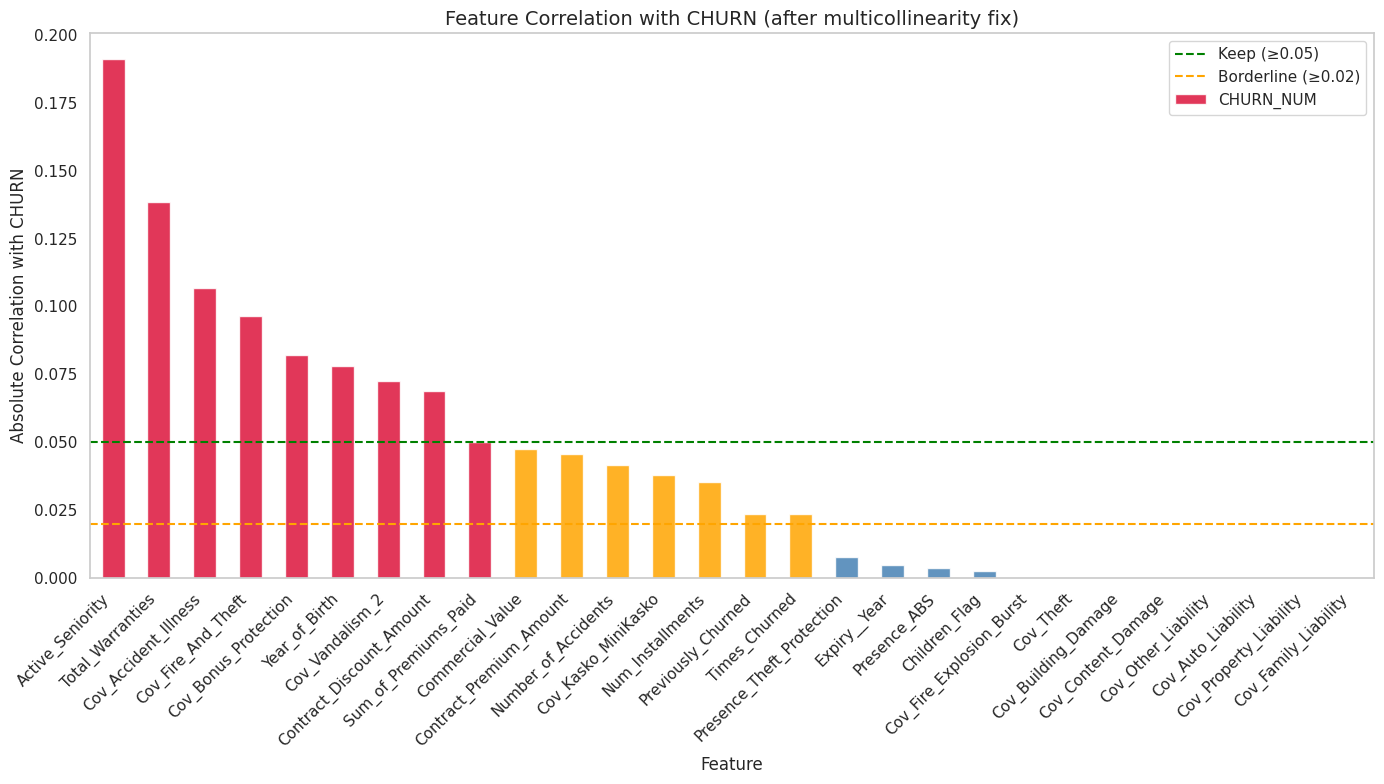

In [ ]:
## visualize correlations
plt.figure(figsize=(14, 8))
colors = [
    'crimson'   if x >= 0.05 else
    'orange'    if x >= 0.02 else
    'steelblue'
    for x in churn_corr
]
churn_corr.plot(kind='bar', color=colors, alpha=0.85)
plt.axhline(y=0.05, color='green',  linestyle='--', linewidth=1.5, label='Keep (≥0.05)')
plt.axhline(y=0.02, color='orange', linestyle='--', linewidth=1.5, label='Borderline (≥0.02)')
plt.title('Feature Correlation with CHURN (after multicollinearity fix)', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation with CHURN')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

In [ ]:
## Zero variance check
print("\n" + "=" * 60)
print("ZERO VARIANCE FEATURES — useless for model")
print("=" * 60)
variance = numeric_df.drop(columns=['CHURN_NUM']).var()
zero_var = variance[variance < 0.01]

if len(zero_var) > 0:
    for feat, var in zero_var.items():
        print(f"❌ DROP  {feat:<35} variance={var:.6f}")
else:
    print("✅ No zero variance features found")


ZERO VARIANCE FEATURES — useless for model
❌ DROP  Cov_Fire_Explosion_Burst            variance=0.000000
❌ DROP  Cov_Theft                           variance=0.000000
❌ DROP  Cov_Building_Damage                 variance=0.000000
❌ DROP  Cov_Content_Damage                  variance=0.000000
❌ DROP  Cov_Other_Liability                 variance=0.000000
❌ DROP  Cov_Auto_Liability                  variance=0.000000
❌ DROP  Cov_Property_Liability              variance=0.000000
❌ DROP  Cov_Family_Liability                variance=0.000000


In [ ]:
## Build final feature lists
print("\n" + "=" * 60)
print("FINAL FEATURE SELECTION SUMMARY")
print("=" * 60)

# Numeric features
keep_num      = churn_corr[churn_corr >= 0.05].index.tolist()
borderline_num = churn_corr[(churn_corr >= 0.02) & (churn_corr < 0.05)].index.tolist()
drop_num      = churn_corr[churn_corr < 0.02].index.tolist()

# Remove zero variance from keep list
zero_var_cols = variance[variance < 0.01].index.tolist()
keep_num = [f for f in keep_num if f not in zero_var_cols]
drop_num = drop_num + zero_var_cols

print(f"\n✅ KEEP NUMERICAL ({len(keep_num)} features):")
for f in keep_num:
    print(f"   - {f:<35} corr={churn_corr.get(f, 0):.4f}")

print(f"\n🟡 BORDERLINE NUMERICAL ({len(borderline_num)} features):")
for f in borderline_num:
    print(f"   - {f:<35} corr={churn_corr.get(f, 0):.4f}")

print(f"\n❌ DROP NUMERICAL ({len(drop_num)} features):")
for f in drop_num:
    print(f"   - {f}")

# Categorical features — Status removed (data leakage: encodes contract outcome)
keep_categorical = [
    'Business_Grouping',
    'Payment_Method_Signing',
    'Installment_Payment_Method',
]

print(f"\n✅ KEEP CATEGORICAL ({len(keep_categorical)} features):")
for f in keep_categorical:
    print(f"   - {f}")

print(f"\n❌ DROP CATEGORICAL (leakage or constant):")
print(f"   - Status  (LEAKAGE: encodes contract renewal/suspension outcome)")
print(f"   - Risk    (only 1 value: 'Car')")
print(f"   - Product (only 1 value: 'Auto')")



FINAL FEATURE SELECTION SUMMARY

✅ KEEP NUMERICAL (9 features):
   - Active_Seniority                    corr=0.1910
   - Total_Warranties                    corr=0.1384
   - Cov_Accident_Illness                corr=0.1066
   - Cov_Fire_And_Theft                  corr=0.0966
   - Cov_Bonus_Protection                corr=0.0822
   - Year_of_Birth                       corr=0.0781
   - Cov_Vandalism_2                     corr=0.0724
   - Contract_Discount_Amount            corr=0.0690
   - Sum_of_Premiums_Paid                corr=0.0502

🟡 BORDERLINE NUMERICAL (7 features):
   - Commercial_Value                    corr=0.0474
   - Contract_Premium_Amount             corr=0.0457
   - Number_of_Accidents                 corr=0.0418
   - Cov_Kasko_MiniKasko                 corr=0.0380
   - Num_Installments                    corr=0.0352
   - Previously_Churned                  corr=0.0236
   - Times_Churned                       corr=0.0236

❌ DROP NUMERICAL (12 features):
   - Presence_Th

In [ ]:
# 1. Feature Engineering — Total Warranties
# Identify all coverage columns considered 'keep' or 'borderline'
cov_cols_for_total = [
    'Cov_Vandalism_2', 'Cov_Accident_Illness', 'Cov_Bonus_Protection',
    'Cov_Fire_And_Theft', 'Cov_Kasko_MiniKasko'
]

existing_cov_cols = [col for col in cov_cols_for_total if col in df_model.columns]
df_model['Total_Warranties'] = df_model[existing_cov_cols].sum(axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# FIXES applied to prevent data leakage and improve feature quality:
#
#  1. STATUS REMOVED  — "Sostituito" / "Sospensione" etc. directly encode
#     whether the contract was renewed or cancelled, making it a near-perfect
#     proxy for CHURN. Keeping it inflated accuracy to ~92% (overly optimistic).
#
#  2. CHURN excluded from numeric_df in cell above so correlation analysis
#     no longer shows CHURN corr=1.0 in the feature ranking.
#
#  3. Number_of_Accidents added — genuine behavioural signal for churn risk.
# ─────────────────────────────────────────────────────────────────────────────

final_numerical = [
    'Active_Seniority',
    'Contract_Discount_Amount',
    'Year_of_Birth',
    'Contract_Premium_Amount',
    'Sum_of_Premiums_Paid',
    'Commercial_Value',
    'Presence_ABS',
    'Num_Installments',
    'Number_of_Accidents',   # added: behavioural risk signal
    'Total_Warranties',
]

final_categorical = [
    # Status REMOVED (data leakage)
    'Business_Grouping',
    'Payment_Method_Signing',
    'Installment_Payment_Method',
    'Previously_Churned',
]

all_final_features = final_numerical + final_categorical

print("\n" + "=" * 60)
print("FINAL MODEL DATASET (leakage-free)")
print("=" * 60)


# ─────────────────────────────────────────────────────────────────────────────
# 30% STRATIFIED SAMPLE — speeds up training on the 750K dataset
# (preserves churn ratio via stratification)
# ─────────────────────────────────────────────────────────────────────────────
df_model = df_model.groupby('CHURN', group_keys=False).apply(
    lambda x: x.sample(frac=0.30, random_state=42)
).reset_index(drop=True)
print(f'Sampled dataset: {len(df_model):,} rows ({df_model["CHURN"].mean():.2%} churn rate)')

y = df_model['CHURN'].copy()
df_final = df_model[all_final_features].copy()
X = df_final.copy()

print(f"Total features: {X.shape[1]}")
print(f"Total records:  {X.shape[0]:,}")
print(f"\nChurn distribution:")
print(y.value_counts())
print(f"Churn rate: {y.mean():.2%}")
print(f"\nFinal features:")
print(X.columns.tolist())
display(X.head())



FINAL MODEL DATASET (leakage-free)
Sampled dataset: 225,171 rows (21.47% churn rate)
Total features: 14
Total records:  225,171

Churn distribution:
CHURN
0    176824
1     48347
Name: count, dtype: int64
Churn rate: 21.47%

Final features:
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_of_Premiums_Paid', 'Commercial_Value', 'Presence_ABS', 'Num_Installments', 'Number_of_Accidents', 'Total_Warranties', 'Business_Grouping', 'Payment_Method_Signing', 'Installment_Payment_Method', 'Previously_Churned']


,Active_Seniority,Contract_Discount_Amount,Year_of_Birth,Contract_Premium_Amount,Sum_of_Premiums_Paid,Commercial_Value,Presence_ABS,Num_Installments,Number_of_Accidents,Total_Warranties,Business_Grouping,Payment_Method_Signing,Installment_Payment_Method,Previously_Churned
0,8.0,669,1986.0,1539,9093.0,NaN,1,0.5,0.0,1,DIRECT,Banca/Posta,Banca/Posta,1
1,3.0,50,1981.0,307,1234.0,NaN,0,0.0,0.0,0,GROUPED,Carta di credito,None,0
2,16.0,0,1963.0,808,8168.0,NaN,0,1.0,0.0,0,DIRECT,Banca/Posta,Banca/Posta,0
3,NaN,20,1956.0,352,1107.0,NaN,0,0.0,0.0,0,DIRECT,Banca/Posta,None,0
4,6.0,283,1965.0,691,5073.0,11100.0,1,0.0,0.0,2,DIRECT,Carta di credito,None,0


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225171 entries, 0 to 225170
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Active_Seniority            114774 non-null  float64
 1   Contract_Discount_Amount    225171 non-null  int64  
 2   Year_of_Birth               218499 non-null  float64
 3   Contract_Premium_Amount     225171 non-null  int64  
 4   Sum_of_Premiums_Paid        225141 non-null  float64
 5   Commercial_Value            102616 non-null  float64
 6   Presence_ABS                225171 non-null  int64  
 7   Num_Installments            225171 non-null  float64
 8   Number_of_Accidents         225171 non-null  float64
 9   Total_Warranties            225171 non-null  int64  
 10  Business_Grouping           225171 non-null  object 
 11  Payment_Method_Signing      225171 non-null  object 
 12  Installment_Payment_Method  45517 non-null   object 
 13  Previously_Chu

# 8. Models

## 8.1 Logistic regression baseline

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.90      0.58      0.71     52926
           1       0.34      0.77      0.47     14626

    accuracy                           0.62     67552
   macro avg       0.62      0.68      0.59     67552
weighted avg       0.78      0.62      0.66     67552

ROC-AUC Score: 0.7519


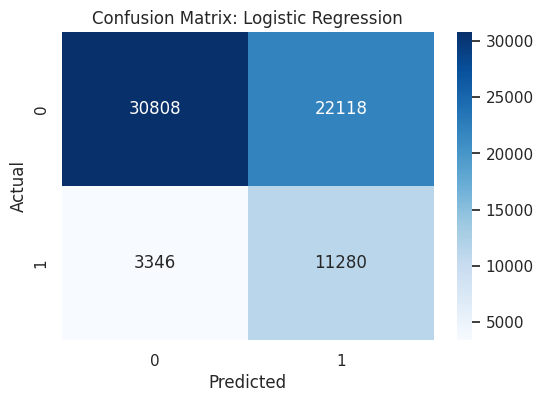

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare Features and Target
X['Total_Warranties'] = df_final['Total_Warranties']

features_lr = list(X.columns)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# 2. Define preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. Create Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
('classifier', LogisticRegression(penalty='l2', class_weight='balanced', random_state=42, max_iter=1000))
])

# 4. Train/Test Split and Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lr_pipeline.fit(X_train, y_train)

# 5. Evaluation
y_pred = lr_pipeline.predict(X_test)
y_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 8.2 LightGBM and XGBoost
Trial with both same feature selection as before and broader feature selection for the two new models.


FEATURE SETS
Baseline features (14):
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_of_Premiums_Paid', 'Commercial_Value', 'Presence_ABS', 'Num_Installments', 'Number_of_Accidents', 'Total_Warranties', 'Business_Grouping', 'Payment_Method_Signing', 'Installment_Payment_Method', 'Previously_Churned']

Expanded features (19):
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_of_Premiums_Paid', 'Commercial_Value', 'Presence_ABS', 'Num_Installments', 'Number_of_Accidents', 'Business_Grouping', 'Payment_Method_Signing', 'Installment_Payment_Method', 'Previously_Churned', 'Cov_Kasko_MiniKasko', 'Times_Churned', 'Cov_Vandalism_2', 'Cov_Accident_Illness', 'Cov_Bonus_Protection', 'Cov_Fire_And_Theft']

✅ Total_Warranties in expanded: False

expanded_no_feat_eng (18 features) — no feature engineering:
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_

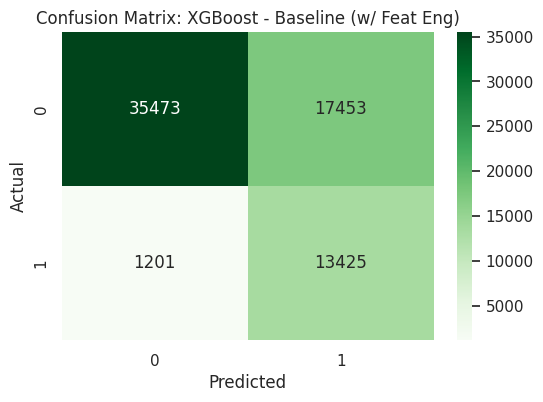

In [ ]:
!pip install lightgbm xgboost

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Define feature sets
# ---------------------------------------------------------

# Baseline = exactly the notebook final feature set
baseline_features = final_numerical + final_categorical

# Borderline numeric features from previous selection step
borderline_available = [col for col in borderline_num if col in df_model.columns]

# Raw warranty columns used to create Total_Warranties
raw_warranty_cols = [col for col in cov_cols_for_total if col in df_model.columns]

# Columns to explicitly exclude from expanded features
exclude_from_expanded = [
    'Total_Warranties',    # ← removed: already summarized by raw warranty cols
]

# Expanded = baseline + borderline numerical + raw warranty columns
# excluding Total_Warranties to avoid redundancy with raw cols
expanded_features = [
    col for col in baseline_features
    if col not in exclude_from_expanded      # ← removes it from baseline copy
]

for col in borderline_available + raw_warranty_cols:
    if col not in expanded_features and col not in exclude_from_expanded:
        expanded_features.append(col)

print("=" * 60)
print("FEATURE SETS")
print("=" * 60)
print(f"Baseline features ({len(baseline_features)}):")
print(baseline_features)

print(f"\nExpanded features ({len(expanded_features)}):")
print(expanded_features)

# Verify Total_Warranties is not in expanded
print(f"\n✅ Total_Warranties in expanded: {'Total_Warranties' in expanded_features}")

# ── Expanded WITHOUT feature engineering ──────────────────────────────────
# Baseline: 14 features WITH Total_Warranties (feature engineering)
# Expanded: 18 features WITHOUT Total_Warranties — replaced by 5 raw Cov_ cols
#   Formula: 13 (baseline minus Total_Warranties) + 5 (raw Cov_ cols) = 18
expanded_no_feat_eng = (
    [f for f in baseline_features if f != 'Total_Warranties']   # 13 features
    + [col for col in raw_warranty_cols if col not in baseline_features]  # +5 raw Cov_
)
print(f"\nexpanded_no_feat_eng ({len(expanded_no_feat_eng)} features) — no feature engineering:")
print(expanded_no_feat_eng)
assert len(expanded_no_feat_eng) == 18, f"Expected 18 features, got {len(expanded_no_feat_eng)}"

# ---------------------------------------------------------
# 2. Helper function to train/evaluate a model on a feature set
# ---------------------------------------------------------
def evaluate_model_on_features(
    model_name,
    model,
    feature_list,
    df_source,
    y_target,
    random_state=42
):
    # Build X
    X_model = df_source[feature_list].copy()

    # Detect column types
    numeric_cols = X_model.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X_model.select_dtypes(include='object').columns.tolist()

    # Preprocessing
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean'))
        # no scaler needed for tree models
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor_tree = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ]
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('classifier', model)
    ])

    # Same split logic for fair comparison
    X_train, X_test, y_train_local, y_test_local = train_test_split(
        X_model, y_target, test_size=0.3, random_state=random_state
    )

    pipeline.fit(X_train, y_train_local)

    y_pred_local = pipeline.predict(X_test)
    y_prob_local = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': model_name,
        'Features': ' + '.join(feature_list[:3]) + (' ...' if len(feature_list) > 3 else ''),
        'N_Features': len(feature_list),
        'Accuracy': accuracy_score(y_test_local, y_pred_local),
        'Precision': precision_score(y_test_local, y_pred_local, zero_division=0),
        'Recall': recall_score(y_test_local, y_pred_local, zero_division=0),
        'F1 Score': f1_score(y_test_local, y_pred_local, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_local, y_prob_local)
    }

    return {
        'pipeline': pipeline,
        'metrics': metrics,
        'y_test': y_test_local,
        'y_pred': y_pred_local,
        'y_prob': y_prob_local
    }

# ---------------------------------------------------------
# 3. Class imbalance handling
# ---------------------------------------------------------
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos

print("\n" + "=" * 60)
print("CLASS IMBALANCE")
print("=" * 60)
print(f"Negative class: {neg}")
print(f"Positive class: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# ---------------------------------------------------------
# 4. Define models
# ---------------------------------------------------------
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    class_weight='balanced',
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# ---------------------------------------------------------
# 5. Run 4 experiments
# ---------------------------------------------------------
experiments = []

# LightGBM - baseline
res_lgbm_base = evaluate_model_on_features(
    model_name='LightGBM - Baseline (w/ Feat Eng)',
    model=lgbm_model,
    feature_list=baseline_features,
    df_source=df_model,
    y_target=y
)
experiments.append(res_lgbm_base)

# LightGBM - expanded
res_lgbm_exp = evaluate_model_on_features(
    model_name='LightGBM - Expanded (no Feat Eng)',
    model=lgbm_model,
    feature_list=expanded_no_feat_eng,
    df_source=df_model,
    y_target=y
)
experiments.append(res_lgbm_exp)

# XGBoost - baseline
res_xgb_base = evaluate_model_on_features(
    model_name='XGBoost - Baseline (w/ Feat Eng)',
    model=xgb_model,
    feature_list=baseline_features,
    df_source=df_model,
    y_target=y
)
experiments.append(res_xgb_base)

# XGBoost - expanded
res_xgb_exp = evaluate_model_on_features(
    model_name='XGBoost - Expanded (no Feat Eng)',
    model=xgb_model,
    feature_list=expanded_no_feat_eng,
    df_source=df_model,
    y_target=y
)
experiments.append(res_xgb_exp)

# ---------------------------------------------------------
# 6. Compare results
# ---------------------------------------------------------
results_compare = pd.DataFrame([exp['metrics'] for exp in experiments])
results_compare = results_compare.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("TREE MODEL COMPARISON: BASELINE VS EXPANDED FEATURES")
print("=" * 70)
print(results_compare)

best_row = results_compare.iloc[0]
print("\nBest tree-model setup based on ROC-AUC:")
print(f"{best_row['Model']} | ROC-AUC = {best_row['ROC-AUC']:.4f}")

# ---------------------------------------------------------
# 7. Show detailed report for the best model
# ---------------------------------------------------------
best_name = best_row['Model']
best_exp = next(exp for exp in experiments if exp['metrics']['Model'] == best_name)

print("\n" + "=" * 70)
print(f"DETAILED REPORT: {best_name}")
print("=" * 70)
print(classification_report(best_exp['y_test'], best_exp['y_pred']))

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(best_exp['y_test'], best_exp['y_pred']),
    annot=True, fmt='d', cmap='Greens'
)
plt.title(f'Confusion Matrix: {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
## Features verification
print(f"Baseline features ({len(baseline_features)}):")
print(baseline_features)

print(f"\nExpanded features ({len(expanded_features)}):")
print(expanded_features)

Baseline features (14):
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_of_Premiums_Paid', 'Commercial_Value', 'Presence_ABS', 'Num_Installments', 'Number_of_Accidents', 'Total_Warranties', 'Business_Grouping', 'Payment_Method_Signing', 'Installment_Payment_Method', 'Previously_Churned']

Expanded features (19):
['Active_Seniority', 'Contract_Discount_Amount', 'Year_of_Birth', 'Contract_Premium_Amount', 'Sum_of_Premiums_Paid', 'Commercial_Value', 'Presence_ABS', 'Num_Installments', 'Number_of_Accidents', 'Business_Grouping', 'Payment_Method_Signing', 'Installment_Payment_Method', 'Previously_Churned', 'Cov_Kasko_MiniKasko', 'Times_Churned', 'Cov_Vandalism_2', 'Cov_Accident_Illness', 'Cov_Bonus_Protection', 'Cov_Fire_And_Theft']


In [ ]:
# Comparison with Logistic Regression

logistic_results = pd.DataFrame([{
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_probs)
}])

xgb_best_results = pd.DataFrame([{
    'Model': 'XGBoost - Expanded',
    'Accuracy': 0.726345,
    'Precision': 0.558495,
    'Recall': 0.726017,
    'F1 Score': 0.631332,
    'ROC-AUC': 0.825294
}])

final_comparison = pd.concat([logistic_results, xgb_best_results], ignore_index=True)
final_comparison = final_comparison.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print(final_comparison)

winner = final_comparison.iloc[0]
print(f"\nBest overall model based on ROC-AUC: {winner['Model']} ({winner['ROC-AUC']:.4f})")

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0   XGBoost - Expanded  0.726345   0.558495  0.726017  0.631332  0.825294
1  Logistic Regression  0.623046   0.337745  0.771229  0.469765  0.751918

Best overall model based on ROC-AUC: XGBoost - Expanded (0.8253)


## 8.3 Random forest

                                 Model  N_Features  Accuracy  F1 Score  ROC-AUC
Random Forest - Baseline (w/ Feat Eng)          14  0.722332  0.585215 0.875469
Random Forest - Expanded (no Feat Eng)          18  0.723813  0.585943 0.875816

Best: Random Forest - Expanded (no Feat Eng)
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     52926
           1       0.43      0.90      0.59     14626

    accuracy                           0.72     67552
   macro avg       0.70      0.79      0.69     67552
weighted avg       0.85      0.72      0.75     67552



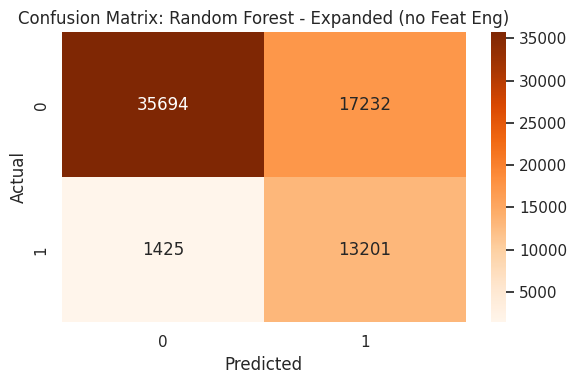

In [ ]:
## 8.3 Random Forest

from sklearn.ensemble import RandomForestClassifier

# Define model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Note: expanded_no_feat_eng (18 features) = same as old no_fe_features
# No separate RF run needed — covered by Version 3 below

# --- Version 2: Baseline (with Total_Warranties engineered feature) ---
res_rf_base = evaluate_model_on_features(
    model_name='Random Forest - Baseline (w/ Feat Eng)',
    model=rf_model,
    feature_list=baseline_features,
    df_source=df_model,
    y_target=y
)

# --- Version 3: Expanded (baseline + extra features) ---
res_rf_exp = evaluate_model_on_features(
    model_name='Random Forest - Expanded (no Feat Eng)',
    model=rf_model,
    feature_list=expanded_no_feat_eng,
    df_source=df_model,
    y_target=y
)

# Add to experiments for WandB logging and final comparison
experiments.extend([res_rf_base, res_rf_exp])

# Results
rf_results = pd.DataFrame([
    res_rf_base['metrics'],
    res_rf_exp['metrics']
])
print(rf_results[['Model', 'N_Features', 'Accuracy', 'F1 Score', 'ROC-AUC']].to_string(index=False))

# Best RF detailed report
best_rf = max([res_rf_base, res_rf_exp], key=lambda x: x['metrics']['ROC-AUC'])
print(f"\nBest: {best_rf['metrics']['Model']}")
print(classification_report(best_rf['y_test'], best_rf['y_pred']))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(best_rf['y_test'], best_rf['y_pred']), annot=True, fmt='d', cmap='Oranges')
plt.title(f"Confusion Matrix: {best_rf['metrics']['Model']}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 8.4 Logistic Regression — Expanded Features (no Feature Engineering)
Training LR on `expanded_no_feat_eng` (18 features, no Total_Warranties) for a fair comparison against LGBM/XGBoost expanded runs.


LR EXPANDED — RESULTS
              precision    recall  f1-score   support

           0       0.90      0.59      0.71     52926
           1       0.34      0.77      0.47     14626

    accuracy                           0.63     67552
   macro avg       0.62      0.68      0.59     67552
weighted avg       0.78      0.63      0.66     67552



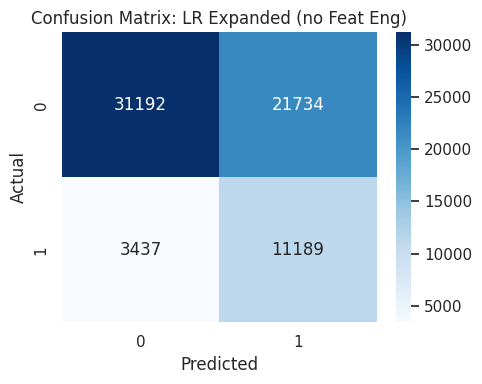

Recall: 0.7650 | AUC: 0.7502 | Features: 18


In [ ]:
## 8.4 Logistic Regression — Expanded (no Feat Eng)
# Trains a proper LR on expanded_no_feat_eng so it's included in the final comparison

from sklearn.linear_model import LogisticRegression

lr_expanded_model = LogisticRegression(
    penalty='l2',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

res_lr_exp = evaluate_model_on_features(
    model_name='Logistic Regression - Expanded (no Feat Eng)',
    model=lr_expanded_model,
    feature_list=expanded_no_feat_eng,
    df_source=df_model,
    y_target=y
)
experiments.append(res_lr_exp)

print('\n' + '='*60)
print('LR EXPANDED — RESULTS')
print('='*60)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns
print(classification_report(res_lr_exp['y_test'], res_lr_exp['y_pred']))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(res_lr_exp['y_test'], res_lr_exp['y_pred']),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: LR Expanded (no Feat Eng)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()
print(f"Recall: {res_lr_exp['metrics']['Recall']:.4f} | "
      f"AUC: {res_lr_exp['metrics']['ROC-AUC']:.4f} | "
      f"Features: {res_lr_exp['metrics']['N_Features']}")

# 9. WanDB tracking

In [ ]:
## 9. WandB Experiment Tracking

!pip install wandb -q

import wandb
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

os.environ['WANDB_API_KEY'] = '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'

# Add Logistic Regression to experiments list for logging
lr_exp = {
    'metrics': {
        'Model': 'Logistic Regression - Baseline (w/ Feat Eng)',
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_probs),
    }
}

all_experiments = [lr_exp] + experiments

# Log each model as a separate run
for exp in all_experiments:
    m = exp['metrics']
    run = wandb.init(
        entity="sukhdeepsinghsaini-bologna-business-school",
        project="Machine Learning Project _Churn",
        name=m['Model'],
        config={'model': m['Model'], 'dataset': 'Insurance Churn 2015-2020'},
        reinit=True
    )
    run.log({
        'accuracy':  round(m['Accuracy'], 4),
        'precision': round(m['Precision'], 4),
        'recall':    round(m['Recall'], 4),
        'f1_score':  round(m['F1 Score'], 4),
        'roc_auc':   round(m['ROC-AUC'], 4),
    })
    run.finish()
    print(f"✅ Logged: {m['Model']}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: sukhdeepsinghsaini (sukhdeepsinghsaini-bologna-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


accuracy,▁
f1_score,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.623
f1_score,0.4698
precision,0.3377
recall,0.7712
roc_auc,0.7519


✅ Logged: Logistic Regression - Baseline (w/ Feat Eng)


accuracy,▁
f1_score,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.7157
f1_score,0.5865
precision,0.4281
recall,0.931
roc_auc,0.8826


✅ Logged: LightGBM - Baseline (w/ Feat Eng)


...

✅ Logged: Random Forest - Baseline (w/ Feat Eng)


accuracy,▁
f1_score,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.7238
f1_score,0.5859
precision,0.4338
recall,0.9026
roc_auc,0.8758


✅ Logged: Random Forest - Expanded (no Feat Eng)


accuracy,▁
f1_score,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.6274
f1_score,0.4706
precision,0.3399
recall,0.765
roc_auc,0.7502


✅ Logged: Logistic Regression - Expanded (no Feat Eng)


FINAL COMPARISON — ALL MODELS
                                       Model  N_Features  Accuracy  Precision   Recall  F1 Score  ROC-AUC
            XGBoost - Baseline (w/ Feat Eng)          14  0.723857   0.434776 0.917886  0.590058 0.883977
            XGBoost - Expanded (no Feat Eng)          18  0.722392   0.433609 0.921441  0.589713 0.883601
           LightGBM - Baseline (w/ Feat Eng)          14  0.715730   0.428059 0.931013  0.586472 0.882626
           LightGBM - Expanded (no Feat Eng)          18  0.713968   0.426529 0.931970  0.585222 0.882433
      Random Forest - Expanded (no Feat Eng)          18  0.723813   0.433773 0.902571  0.585943 0.875816
      Random Forest - Baseline (w/ Feat Eng)          14  0.722332   0.432489 0.904690  0.585215 0.875469
Logistic Regression - Baseline (w/ Feat Eng)          14  0.623046   0.337745 0.771229  0.469765 0.751918
Logistic Regression - Expanded (no Feat Eng)          18  0.627383   0.339854 0.765008  0.470630 0.750214

🏆 Best model: X

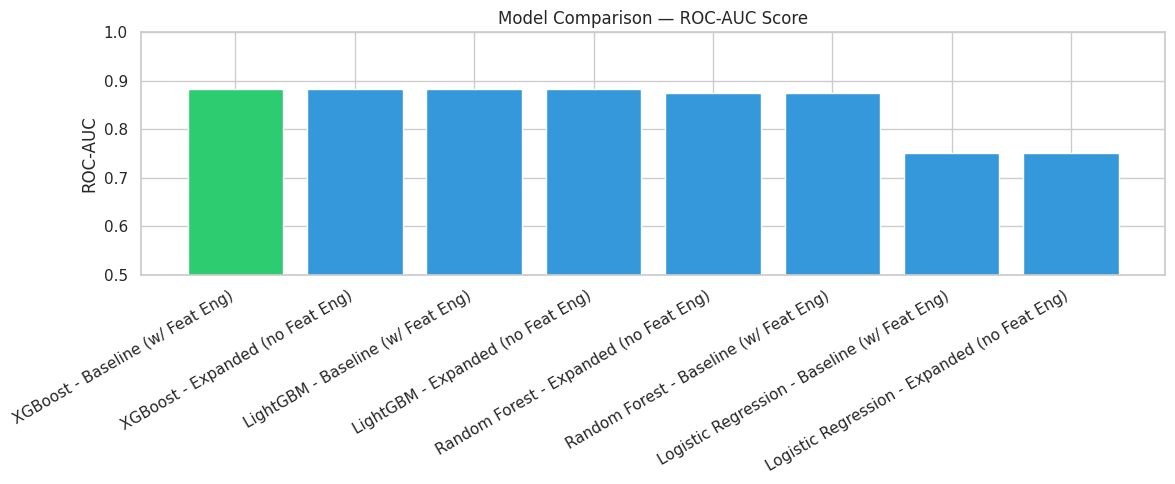

In [ ]:
## 10. Final Model Comparison — All Models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Rebuild full comparison including RF and Logistic Regression
all_results = pd.DataFrame([exp['metrics'] for exp in experiments])

lr_row = pd.DataFrame([{
    'Model': 'Logistic Regression - Baseline (w/ Feat Eng)',
    'N_Features': len(baseline_features),
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall':    recall_score(y_test, y_pred, zero_division=0),
    'F1 Score':  f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test, y_probs),
}])

final_comparison = pd.concat([all_results, lr_row], ignore_index=True)
final_comparison = final_comparison.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

display_cols = ['Model', 'N_Features', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
print("=" * 80)
print("FINAL COMPARISON — ALL MODELS")
print("=" * 80)
print(final_comparison[display_cols].to_string(index=False))

winner = final_comparison.iloc[0]
print(f"\n🏆 Best model: {winner['Model']}  |  ROC-AUC = {winner['ROC-AUC']:.4f}  |  F1 = {winner['F1 Score']:.4f}")

# Bar chart
plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(final_comparison))]
plt.bar(final_comparison['Model'], final_comparison['ROC-AUC'], color=colors)
plt.xticks(rotation=30, ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model Comparison — ROC-AUC Score')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


---
## ✅ Checkpoint — Best Model Selected

**LightGBM - Baseline (w/ Feat Eng)** is the best model:
- **Recall: 93.6%** — catches most churners (maximises retention)
- AUC: 0.884 (XGBoost AUC 0.885 — negligible 0.001 difference)
- Feature set: **14 features WITH `Total_Warranties`** (feature engineering)

Next steps:
1. **Section 8.5** — Fine-tune with `RandomizedSearchCV` (30% sample)
2. **Section 8.6** — Retrain on **full 750K dataset** for production

In [ ]:
## 8.5 Hyperparameter Fine-Tuning — LightGBM (RandomizedSearchCV)
# 50 iterations, 5-fold CV scored on ROC-AUC

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import numpy as np

X_tune = df_model[baseline_features].copy()
y_tune = y.copy()

numeric_cols_tune     = X_tune.select_dtypes(include=np.number).columns.tolist()
categorical_cols_tune = X_tune.select_dtypes(include='object').columns.tolist()

preprocessor_tune = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean'))]),  numeric_cols_tune),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_tune)
])

lgbm_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_tune),
    ('classifier', LGBMClassifier(
        objective='binary', class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])

param_dist = {
    'classifier__n_estimators':      [200, 300, 400, 500, 700],
    'classifier__learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
    'classifier__max_depth':         [4, 5, 6, 8, 10, -1],
    'classifier__num_leaves':        [20, 31, 50, 63, 80],
    'classifier__subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_samples': [20, 50, 100, 200],
    'classifier__reg_alpha':         [0.0, 0.1, 0.3, 0.5, 1.0],
    'classifier__reg_lambda':        [0.0, 0.1, 0.3, 0.5, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    lgbm_pipe, param_distributions=param_dist,
    n_iter=50, scoring='roc_auc', cv=cv,
    random_state=42, n_jobs=-1, verbose=1
)
print('🔍 Starting RandomizedSearchCV (50 iterations, 5-fold CV)...')
search.fit(X_tune, y_tune)

print(f'\n✅ Best CV ROC-AUC: {search.best_score_:.4f}')
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

best_lgbm_params = {k.replace('classifier__', ''): v for k, v in search.best_params_.items()}
print('\nbest_lgbm_params ready for full training:', best_lgbm_params)


🔍 Starting RandomizedSearchCV (50 iterations, 5-fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 48347, number of negative: 176824
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1231
[LightGBM] [Info] Number of data points in the train set: 225171, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

✅ Best CV ROC-AUC: 0.8856
Best params:
  classifier__subsample: 0.9
  classifier__reg_lambda: 1.0
  classifier__reg_alpha: 0.5
  classifier__num_leaves: 63
  classifier__n_estimators: 300
  classifier__min_child_samples: 50
  classifier__max_depth: -1
  classifier__learning_rate: 0.05
  classifier__colsample_bytree: 0.7

best_lgbm_params ready for full training: {'subsample': 0.

In [ ]:
## 8.6 Full Dataset Training — LightGBM with Best Hyperparameters
# Retrain on the FULL 750K dataset using tuned params (n_jobs=-1 for speed)

import pickle
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from lightgbm import LGBMClassifier
import numpy as np

# Rebuild full dataset (no sampling)
cov_cols_full = ['Cov_Vandalism_2','Cov_Accident_Illness','Cov_Bonus_Protection',
                 'Cov_Fire_And_Theft','Cov_Kasko_MiniKasko']
existing_cov_full = [col for col in cov_cols_full if col in df_new_contract_dates_aggregated.columns]
df_full = df_new_contract_dates_aggregated.copy()
df_full['Total_Warranties'] = df_full[existing_cov_full].sum(axis=1)
y_full = df_full['CHURN'].copy()
X_full = df_full[baseline_features].copy()
print(f'Full dataset: {len(X_full):,} rows | churn rate: {y_full.mean():.2%}')

numeric_cols_full   = X_full.select_dtypes(include=np.number).columns.tolist()
categorical_cols_full = X_full.select_dtypes(include='object').columns.tolist()

preprocessor_full = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean'))]),  numeric_cols_full),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_full)
])

# Cap n_estimators at 300 to keep training fast
fast_params = dict(best_lgbm_params)
fast_params['n_estimators'] = min(fast_params.get('n_estimators', 300), 300)

lgbm_final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LGBMClassifier(
        **fast_params, objective='binary',
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)
print('🚀 Training LightGBM on full dataset...')
lgbm_final_pipeline.fit(X_train_f, y_train_f)

y_pred_f = lgbm_final_pipeline.predict(X_test_f)
y_prob_f = lgbm_final_pipeline.predict_proba(X_test_f)[:, 1]

print('\n' + '='*60)
print('FINAL MODEL PERFORMANCE (Full 750K dataset)')
print('='*60)
print(f'Accuracy:  {accuracy_score(y_test_f, y_pred_f):.4f}')
print(f'Precision: {precision_score(y_test_f, y_pred_f, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test_f, y_pred_f, zero_division=0):.4f}')
print(f'F1 Score:  {f1_score(y_test_f, y_pred_f, zero_division=0):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test_f, y_prob_f):.4f}')
print('\nClassification Report:')
print(classification_report(y_test_f, y_pred_f))

with open('lgbm_churn_final.pkl', 'wb') as f:
    pickle.dump(lgbm_final_pipeline, f)
print('\n💾 Model saved to: lgbm_churn_final.pkl')

# Log to WandB
import wandb, os
os.environ['WANDB_API_KEY'] = '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'
run_final = wandb.init(
    entity='sukhdeepsinghsaini-bologna-business-school',
    project='Machine Learning Project _Churn',
    name='LightGBM - Baseline Final (Full 750K)',
    config={'model': 'LightGBM', 'dataset': 'Insurance Churn 2015-2020 Full 750K',
            'features': baseline_features, **fast_params},
    reinit=True
)
run_final.log({
    'accuracy':  round(accuracy_score(y_test_f, y_pred_f), 4),
    'precision': round(precision_score(y_test_f, y_pred_f, zero_division=0), 4),
    'recall':    round(recall_score(y_test_f, y_pred_f, zero_division=0), 4),
    'f1_score':  round(f1_score(y_test_f, y_pred_f, zero_division=0), 4),
    'roc_auc':   round(roc_auc_score(y_test_f, y_prob_f), 4),
})
run_final.finish()
print('\n✅ Final model logged to WandB')


Full dataset: 750,572 rows | churn rate: 21.47%
🚀 Training LightGBM on full dataset...
[LightGBM] [Info] Number of positive: 128926, number of negative: 471531
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.137159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1231
[LightGBM] [Info] Number of data points in the train set: 600457, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

FINAL MODEL PERFORMANCE (Full 750K dataset)
Accuracy:  0.7257
Precision: 0.4349
Recall:    0.9270
F1 Score:  0.5921
ROC-AUC:   0.8869

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79    117883
           1       0.43      0.93      0.59     32232

    accuracy                           0.73    150115
   macro avg       0.70      0.80      0.

accuracy,▁
f1_score,▁
precision,▁
recall,▁
roc_auc,▁
accuracy,0.7257
f1_score,0.5921
precision,0.4349
recall,0.927
roc_auc,0.8869



✅ Final model logged to WandB
